# Lesson 2 — From raw table to analysable data

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/djnzx/ida-practice-3d/blob/main/practice/2/2-practice.ipynb)

Intellectual Data Analysis — practical part, lesson 2 of 3.

## Learning objectives

By the end of this session you should be able to:

- explain what a pandas index is and predict when an operation will change
  it;
- select rows and columns with `[]`, `.loc` and `.iloc` and say which one
  is correct for a given task, including why chained assignment is unsafe;
- diagnose missingness as a pattern rather than a nuisance, distinguish
  MCAR, MAR and MNAR on a real table, and show that two imputation
  strategies produce two different distributions;
- perform a split-apply-combine aggregation and explain what happened to
  the index;
- choose a chart from the question being asked, and defend a bin count, a
  bandwidth and an outlier rule as decisions rather than defaults;
- state why `LabelEncoder` on a nominal feature is wrong and encode it
  correctly instead;
- fit a scaler on training data only, and explain what leaks if you do not;
- read an explained-variance curve, and state what t-SNE does and does not
  let you conclude.

## Prerequisites

Lesson 1. Specifically: `ndarray` anatomy (Practice 1 §3.2), views and
copies (Practice 1 §3.6), broadcasting (Practice 1 §3.7), axis semantics
(Practice 1 §3.8), boolean masking (Practice 1 §3.9), `NaN` (Practice 1 §3.10),
and seeded generation with `default_rng` (Practice 1 §4.1).

## Practicalities

- Written for **90-120 minutes** (2 to 3 academic hours) of class time.
- Measured end-to-end execution time: **about 20 seconds** on a clean
  kernel (reference machine, CPython 3.9, no GPU). The three t-SNE fits in
  §15 account for most of it; they run on a 50-component PCA reduction
  rather than the raw 784 columns, which is both standard practice and
  several times faster. Every number in the notebook is seeded and
  reproduces exactly on a re-run.
- Homework: `2-homework.ipynb`, 3-4 hours.

## How this lesson fits

Lesson 1 built arrays. This lesson attaches names, an index, and the
possibility of a missing value — which is to say, it turns an array into a
table, and a table is what real data arrives as. The work here is
*preparation and understanding*: by the end you will have a Titanic frame
that is clean, encoded and scaled, together with a written record of every
decision that produced it, and a two-dimensional projection of a
784-dimensional dataset. Lesson 3 models both.

## The datasets

Four files, each read from its full address at the point of use. No dataset
in this course appears by calling a loader function; see
`practice/datasets/README.md` for the provenance of each.

| File | What it is | Used for |
|---|---|---|
| `titanic.csv` | 891 passengers, 12 columns, real missing values | missingness, grouping, encoding, Simpson's paradox |
| `wine.csv` | 178 wines, 13 measurements plus cultivar | correlation structure, pairplots |
| `iris.csv` | 150 flowers, 4 measurements plus species | the clean-data baseline |
| `bike_sharing_hourly.csv` | 17 379 hours of bicycle rentals | dates, mixed schema, integer-coded categories |
| `mnist_sample.csv` | 1500 handwritten digits, 784 pixels each | PCA and t-SNE |

## 1. Configuration

As in Lesson 1: imports, one seed, display settings, printed versions. No
data locations — every address is written out where the data is loaded.

Two additions relative to Lesson 1. `pd.set_option('display.max_columns',
None)` stops pandas truncating wide tables with an ellipsis, which matters
when the point of a cell is a column you cannot see. `sns.set_theme()` sets
seaborn's defaults for every matplotlib figure, including the ones drawn
without seaborn.

In [201]:
import sys

import numpy as np
import pandas as pd
import matplotlib
import matplotlib.pyplot as plt
import seaborn as sns

SEED = 20250919
rng = np.random.default_rng(SEED)

# Display settings, set once.
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 120)
pd.set_option("display.float_format", lambda v: f"{v:,.4f}")

sns.set_theme(style="whitegrid", context="notebook")
plt.rcParams["figure.figsize"] = (7.0, 4.5)
plt.rcParams["figure.dpi"] = 110

print("python     ", sys.version.split()[0])
print("numpy      ", np.__version__)
print("pandas     ", pd.__version__)
print("matplotlib ", matplotlib.__version__)
print("seaborn    ", sns.__version__)

python      3.13.15
numpy       2.1.3
pandas      2.2.3
matplotlib  3.10.0
seaborn     0.13.2


## 2. Series and DataFrame

### 2.1 A Series is an array plus an index

Start from the array of Lesson 1 and add the one thing pandas contributes.

In [202]:
values = np.array([10.0, 20.0, 30.0, 40.0])
series = pd.Series(values, index=["a", "b", "c", "d"], name="measurement")

print(series)
print()
print("the values are still an ndarray:", type(series.values).__name__, series.values.dtype)
print("the index is the new part      :", list(series.index))

a   10.0000
b   20.0000
c   30.0000
d   40.0000
Name: measurement, dtype: float64

the values are still an ndarray: ndarray float64
the index is the new part      : ['a', 'b', 'c', 'd']


The numbers are the array from Lesson 1, unchanged. The index is a second
array of labels aligned to it. That is the whole of the difference, and it
buys three things: lookup by label, automatic alignment between objects,
and a place to record what a row *is* rather than merely where it sits.

Alignment is the property worth seeing immediately, because it is the one
that surprises people:

In [203]:
left = pd.Series([1, 2, 3], index=["a", "b", "c"])
right = pd.Series([10, 20, 30], index=["c", "b", "a"])   # same labels, other order

print("left + right:")
print(left + right)
print()
print("The addition matched on the LABEL, not on the position.")
print("Positionally it would have been 11, 22, 33.")

left + right:
a    31
b    22
c    13
dtype: int64

The addition matched on the LABEL, not on the position.
Positionally it would have been 11, 22, 33.


With NumPy arrays that addition would have paired the first element with
the first element. pandas pairs `a` with `a`. When the labels do not match
at all, the result is `NaN` rather than an error:

In [204]:
mismatched = pd.Series([100, 200], index=["c", "z"])
print(left + mismatched)
print()
print("'z' exists in one operand only, so the sum is unknown -> NaN.")

a        NaN
b        NaN
c   103.0000
z        NaN
dtype: float64

'z' exists in one operand only, so the sum is unknown -> NaN.


This is the single most common source of unexpected `NaN` in pandas code.
When an arithmetic result is full of `NaN` and you cannot see why, print
the two indexes and compare them.

### 2.2 A DataFrame is a dict of Series sharing one index

The draft built a `DataFrame` from a NumPy array plus a list of column
names. That is still the clearest way to see the structure.

In [205]:
matrix = rng.normal(0, 1, size=(6, 4)).round(3)
frame = pd.DataFrame(matrix, columns=["A", "B", "C", "D"])

print(frame)
print()
print("shape  ", frame.shape)
print("columns", list(frame.columns))
print("index  ", list(frame.index), "  <- a default RangeIndex, created for you")

        A       B       C       D
0 -0.8400 -1.3860  0.0490 -0.4280
1 -0.2490  0.5290 -1.3420 -1.0580
2 -0.6580 -0.0100 -0.9190  0.7680
3 -1.1110  1.0600  0.0220  0.3590
4  0.2240  1.0380 -0.0810  0.7500
5  0.1890  1.2070  1.1310 -0.7820

shape   (6, 4)
columns ['A', 'B', 'C', 'D']
index   [0, 1, 2, 3, 4, 5]   <- a default RangeIndex, created for you


There are two axes of labels: the index down the side and the columns
across the top. Both are `Index` objects; the columns are not special.

### 2.3 Selecting columns

A single column is a `Series`. A list of columns is a `DataFrame`. This
distinction causes real confusion, so make the types explicit.

In [206]:
print("frame['A'] is a", type(frame["A"]).__name__)
print(frame["A"].head(3))
print()
print("frame[['A', 'C']] is a", type(frame[["A", "C"]]).__name__)
print(frame[["A", "C"]].head(3))

frame['A'] is a Series
0   -0.8400
1   -0.2490
2   -0.6580
Name: A, dtype: float64

frame[['A', 'C']] is a DataFrame
        A       C
0 -0.8400  0.0490
1 -0.2490 -1.3420
2 -0.6580 -0.9190


The double brackets are not a style choice. `frame["A"]` asks for one
column and gets a 1-D object; `frame[["A"]]` passes a *list of one name*
and gets a 2-D object with one column. scikit-learn wants the 2-D form for
`X`, exactly as in Practice 1 §3.5.

In [207]:
print("frame['A'] shape  ", frame["A"].shape, "  1-D")
print("frame[['A']] shape", frame[["A"]].shape, " 2-D")

frame['A'] shape   (6,)   1-D
frame[['A']] shape (6, 1)  2-D


Chained selection works and is worth understanding rather than using:

In [208]:
print(frame[["A", "C"]]["A"].head(3))
print()
print("This built an intermediate two-column DataFrame and then threw")
print("one column away. frame['A'] does the same job in one step.")

0   -0.8400
1   -0.2490
2   -0.6580
Name: A, dtype: float64

This built an intermediate two-column DataFrame and then threw
one column away. frame['A'] does the same job in one step.


### 2.4 Derived columns

Assigning to a name that does not exist creates a column. The right-hand
side is aligned on the index, so the arithmetic is elementwise per row.

In [209]:
frame["E"] = frame["A"] + frame["B"]
frame["above_average_A"] = frame["A"] > frame["A"].mean()

print(frame)
print()
print("dtypes:")
print(frame.dtypes)

        A       B       C       D       E  above_average_A
0 -0.8400 -1.3860  0.0490 -0.4280 -2.2260            False
1 -0.2490  0.5290 -1.3420 -1.0580  0.2800             True
2 -0.6580 -0.0100 -0.9190  0.7680 -0.6680            False
3 -1.1110  1.0600  0.0220  0.3590 -0.0510            False
4  0.2240  1.0380 -0.0810  0.7500  1.2620             True
5  0.1890  1.2070  1.1310 -0.7820  1.3960             True

dtypes:
A                  float64
B                  float64
C                  float64
D                  float64
E                  float64
above_average_A       bool
dtype: object


Note the `bool` dtype on the derived flag. pandas tracks a type per column,
not per table, which is §3.

### 2.5 The elementwise mask surprise

The drafts showed `df[df > 0]` and moved on. It does not do what most
people read it as doing, so it is worth a cell of its own.

In [210]:
numeric = frame[["A", "B", "C", "D"]]

print("numeric > 0 is a DataFrame of booleans, same shape:")
print((numeric > 0).head(3))
print()
print("numeric[numeric > 0] keeps the shape and blanks the rest:")
print(numeric[numeric > 0].head(3))

numeric > 0 is a DataFrame of booleans, same shape:
       A      B      C      D
0  False  False   True  False
1  False   True  False  False
2  False  False  False   True

numeric[numeric > 0] keeps the shape and blanks the rest:
    A      B      C      D
0 NaN    NaN 0.0490    NaN
1 NaN 0.5290    NaN    NaN
2 NaN    NaN    NaN 0.7680


**It did not filter rows.** It returned a frame of exactly the same shape
in which every position failing the condition has been replaced by `NaN`.
That is the documented behaviour of masking a `DataFrame` with a
same-shaped boolean `DataFrame`: there is no way to remove individual
cells from a rectangle, so pandas blanks them instead.

Row filtering needs a boolean **Series** — one value per row, not one per
cell:

In [211]:
print("filtering rows where column A is positive:")
print(numeric[numeric["A"] > 0])
print()
print("rows kept:", len(numeric[numeric["A"] > 0]), "of", len(numeric))
print("no NaN introduced:", not numeric[numeric["A"] > 0].isna().any().any())

filtering rows where column A is positive:
       A      B       C       D
4 0.2240 1.0380 -0.0810  0.7500
5 0.1890 1.2070  1.1310 -0.7820

rows kept: 2 of 6
no NaN introduced: True


The rule: **a boolean `DataFrame` blanks cells, a boolean `Series` selects
rows.** If your filter produced `NaN` where you expected fewer rows, you
wrote the first when you meant the second.

## 3. Types, and the first look at a real table

Load the Titanic passenger list. The address is written out in full, here
and at every other load in this course.

In [212]:
# import pandas as pd

titanic = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)

print("shape:", titanic.shape)
titanic.head()

shape: (891, 12)


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0000,0,0,373450,8.0500,NaN,S


In [213]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
# titanic = pd.read_csv("../datasets/titanic.csv")
# print("shape:", titanic.shape)
# titanic.head()

### 3.1 `info()` as a diagnostic

`info()` is usually run as a formality. Read it properly: it is the fastest
statement of what is wrong with a table.

In [214]:
titanic.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


Three things in that output matter.

**The non-null counts.** The table has 891 rows. `Age` has 714 non-null,
`Cabin` has 204, `Embarked` has 889. Those three columns have gaps and the
others do not — that is §5.

**The dtypes.** Seven numeric columns and five `object` columns.

**The memory usage**, which is the Practice 1 §3.2 `nbytes` idea applied to a
table.

### 3.2 `object` is pandas saying "I gave up"

A column of dtype `object` holds Python objects and pointers to them, like
the list of Practice 1 §2.2. It is what pandas falls back to when a column is
not uniformly numeric — usually strings, sometimes a numeric column with
one contaminated entry.

In [215]:
print(titanic.dtypes.value_counts())
print()
print("the object columns:", list(titanic.dtypes[titanic.dtypes == "object"].index))

int64      5
object     5
float64    2
Name: count, dtype: int64

the object columns: ['Name', 'Sex', 'Ticket', 'Cabin', 'Embarked']


`Name`, `Sex`, `Ticket`, `Cabin` and `Embarked` are genuinely text. But
`object` does not tell you that — it only tells you "not numeric". Here is
the dangerous case, constructed deliberately:

In [216]:
contaminated = pd.Series(["1.5", "2.5", "not measured", "4.0"])
print("dtype:", contaminated.dtype, " <- object, because of one bad entry")

# Arithmetic silently does the wrong thing rather than failing:
print("sum   :", contaminated.sum(), "  <- string concatenation")

# The repair, with the failure made explicit:
coerced = pd.to_numeric(contaminated, errors="coerce")
print("\nafter pd.to_numeric(errors='coerce'):")
print(coerced)
print("dtype:", coerced.dtype, " sum:", coerced.sum(), " missing:", coerced.isna().sum())

dtype: object  <- object, because of one bad entry
sum   : 1.52.5not measured4.0   <- string concatenation

after pd.to_numeric(errors='coerce'):
0   1.5000
1   2.5000
2      NaN
3   4.0000
dtype: float64
dtype: float64  sum: 8.0  missing: 1


`errors="coerce"` turns what it cannot parse into `NaN`, which converts an
invisible problem into a visible one that §5 knows how to handle. This is
the pandas version of Practice 1 §3.2, where one string in a list turned an
entire NumPy array into text.

### 3.3 `describe`, and what it leaves out

`describe()` silently reports on the numeric columns only. That is a
reasonable default and a trap: a column missing from the output is not a
column without problems.

In [217]:
titanic.describe()

,PassengerId,Survived,Pclass,Age,SibSp,Parch,Fare
count,891.0000,891.0000,891.0000,714.0000,891.0000,891.0000,891.0000
mean,446.0000,0.3838,2.3086,29.6991,0.5230,0.3816,32.2042
std,257.3538,0.4866,0.8361,14.5265,1.1027,0.8061,49.6934
min,1.0000,0.0000,1.0000,0.4200,0.0000,0.0000,0.0000
25%,223.5000,0.0000,2.0000,20.1250,0.0000,0.0000,7.9104
50%,446.0000,0.0000,3.0000,28.0000,0.0000,0.0000,14.4542
75%,668.5000,1.0000,3.0000,38.0000,1.0000,0.0000,31.0000
max,891.0000,1.0000,3.0000,80.0000,8.0000,6.0000,512.3292


Five of the twelve columns are absent from that table, and `PassengerId` —
which is an identifier, not a measurement — is present, with a mean.
`include="all"` covers everything, at the cost of a sparser table:

In [218]:
titanic.describe(include="all")

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
count,891.0000,891.0000,891.0000,891,891,714.0000,891.0000,891.0000,891,891.0000,204,889
unique,NaN,NaN,NaN,891,2,NaN,NaN,NaN,681,NaN,147,3
top,NaN,NaN,NaN,"Dooley, Mr. Patrick",male,NaN,NaN,NaN,347082,NaN,G6,S
freq,NaN,NaN,NaN,1,577,NaN,NaN,NaN,7,NaN,4,644
mean,446.0000,0.3838,2.3086,NaN,NaN,29.6991,0.5230,0.3816,NaN,32.2042,NaN,NaN
std,257.3538,0.4866,0.8361,NaN,NaN,14.5265,1.1027,0.8061,NaN,49.6934,NaN,NaN
min,1.0000,0.0000,1.0000,NaN,NaN,0.4200,0.0000,0.0000,NaN,0.0000,NaN,NaN
25%,223.5000,0.0000,2.0000,NaN,NaN,20.1250,0.0000,0.0000,NaN,7.9104,NaN,NaN
50%,446.0000,0.0000,3.0000,NaN,NaN,28.0000,0.0000,0.0000,NaN,14.4542,NaN,NaN
75%,668.5000,1.0000,3.0000,NaN,NaN,38.0000,1.0000,0.0000,NaN,31.0000,NaN,NaN


For the text columns pandas now reports `count`, `unique`, `top` and
`freq`. Note `Name` has 891 unique values in 891 rows — it is an
identifier. `Sex` has 2. `Ticket` has 681, so some tickets are shared,
which is a fact about families travelling together.

Reading `describe` on a subset is the same operation on fewer columns:

In [219]:
titanic[["Age", "Fare"]].describe()

,Age,Fare
count,714.0000,891.0000
mean,29.6991,32.2042
std,14.5265,49.6934
min,0.4200,0.0000
25%,20.1250,7.9104
50%,28.0000,14.4542
75%,38.0000,31.0000
max,80.0000,512.3292


`Age` runs from 0.42 to 80 and `Fare` from 0 to 512. A fare of 0 is worth
noticing; so is the gap between the 75th percentile of `Fare` (31) and its
maximum (512). §8 returns to that.

### 3.4 Counting categories

`value_counts()` is the categorical counterpart of `describe`.

In [220]:
print(titanic["Pclass"].value_counts())
print()
print(titanic["Sex"].value_counts())
print()
print("as proportions:")
print(titanic["Survived"].value_counts(normalize=True))

Pclass
3    491
1    216
2    184
Name: count, dtype: int64

Sex
male      577
female    314
Name: count, dtype: int64

as proportions:
Survived
0   0.6162
1   0.3838
Name: proportion, dtype: float64


`value_counts` sorts by frequency by default and **excludes missing values
by default**. Both are usually what you want and neither is obvious; pass
`dropna=False` when the number of missing values is part of the question.

In [221]:
print("Embarked, missing values hidden (the default):")
print(titanic["Embarked"].value_counts())
print()
print("Embarked, missing values shown:")
print(titanic["Embarked"].value_counts(dropna=False))

Embarked, missing values hidden (the default):
Embarked
S    644
C    168
Q     77
Name: count, dtype: int64

Embarked, missing values shown:
Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64


That last line is the only one of the two that tells you the column has a
problem.

The survival split — about 62 % died, 38 % survived — is the **class
balance**, and Practice 3 §9 uses it: a model that predicts "died" for every
passenger is already 62 % accurate while having learned nothing.

## 4. Selection done properly: `[]`, `.loc`, `.iloc`

Three ways to select, with different rules. Learn the distinction once
here; every later section depends on it.

- `frame[...]` is a convenience. Given a string it selects a **column**;
  given a boolean Series it selects **rows**. The same syntax, two
  meanings, decided by the type of what you passed.
- `frame.loc[rows, columns]` selects by **label**.
- `frame.iloc[rows, columns]` selects by **integer position**.

Use `.loc` and `.iloc` whenever you are doing anything other than grabbing
a column, because they say which axis you mean and they cannot be
misread.

In [222]:
small = titanic.loc[0:4, ["Name", "Sex", "Age", "Fare"]]
print(small)

                                                Name     Sex     Age    Fare
0                            Braund, Mr. Owen Harris    male 22.0000  7.2500
1  Cumings, Mrs. John Bradley (Florence Briggs Th...  female 38.0000 71.2833
2                             Heikkinen, Miss. Laina  female 26.0000  7.9250
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)  female 35.0000 53.1000
4                           Allen, Mr. William Henry    male 35.0000  8.0500


Note that `.loc[0:4]` returned **five** rows, not four. `.loc` slices are
inclusive of the endpoint, because a label slice has no notion of "one
past the end". `.iloc` slices are half-open like Python's, exclusive of
the endpoint.

In [223]:
print("loc[0:4]  rows:", len(titanic.loc[0:4]), " (label slice, endpoint included)")
print("iloc[0:4] rows:", len(titanic.iloc[0:4]), " (positional slice, endpoint excluded)")

loc[0:4]  rows: 5  (label slice, endpoint included)
iloc[0:4] rows: 4  (positional slice, endpoint excluded)


On this table the index happens to be `0, 1, 2, ...`, so label and
position coincide and the difference looks academic. Make them diverge and
it stops being academic:

In [224]:
# Sort by fare. The rows move; their labels travel with them.
by_fare = titanic.sort_values("Fare", ascending=False)

print("first three rows after sorting, by POSITION (iloc):")
print(by_fare.iloc[0:3][["Name", "Fare"]])
print()
print("the row labelled 0 is still the same passenger (loc):")
print(by_fare.loc[[0]][["Name", "Fare"]])

first three rows after sorting, by POSITION (iloc):
                                   Name     Fare
679  Cardeza, Mr. Thomas Drake Martinez 512.3292
258                    Ward, Miss. Anna 512.3292
737              Lesurer, Mr. Gustave J 512.3292

the row labelled 0 is still the same passenger (loc):
                      Name   Fare
0  Braund, Mr. Owen Harris 7.2500


`.iloc[0]` is "whatever is first now". `.loc[0]` is "the passenger that was
row 0 when the file was read". After any sort, filter or grouping, those
are different questions. Choosing the wrong one produces a result that is
wrong without being an error.

### 4.1 Boolean selection

A condition on a column gives a boolean Series, which selects rows (§2.5).

In [225]:
children = titanic[titanic["Age"] < 12]
print("passengers under 12:", len(children))
print("their survival rate:", round(children["Survived"].mean(), 4))
print("overall survival rate:", round(titanic["Survived"].mean(), 4))

passengers under 12: 68
their survival rate: 0.5735
overall survival rate: 0.3838


Combine conditions with `&` and `|`, each condition in parentheses —
exactly as for NumPy arrays in Practice 1 §3.9, and for the same reason.

In [226]:
first_class_women = titanic[(titanic["Pclass"] == 1) & (titanic["Sex"] == "female")]
print("first-class women:", len(first_class_women),
      " survival rate:", round(first_class_women["Survived"].mean(), 4))

third_class_men = titanic[(titanic["Pclass"] == 3) & (titanic["Sex"] == "male")]
print("third-class men  :", len(third_class_men),
      " survival rate:", round(third_class_men["Survived"].mean(), 4))

first-class women: 94  survival rate: 0.9681
third-class men  : 347  survival rate: 0.1354


A survival rate of 0.97 against 0.14. That gap is the strongest signal in
this dataset and §11 shows what happens if you look at only one of the two
variables at a time.

### 4.2 The chained assignment trap

This is the pandas equivalent of Practice 1 §3.6 and it is the most common
way to write pandas code that silently does nothing.

Suppose you want to set the missing ages of third-class passengers to a
placeholder. The natural-looking way is wrong:

In [227]:
# DELIBERATE BUG. Two bracket operations chained across an assignment.
demo = titanic.copy()

import warnings
with warnings.catch_warnings(record=True) as caught:
    warnings.simplefilter("always")
    demo[demo["Pclass"] == 3]["Age"] = -1      # assigns into a temporary

    print("warnings raised:", len(caught))
    for w in caught:
        first_line = next(l for l in str(w.message).split("\n") if l.strip())
        print(" ", w.category.__name__ + ":", first_line.strip())

print()
print("did anything change? ages equal to -1:", int((demo["Age"] == -1).sum()))

warnings raised: 1

did anything change? ages equal to -1: 0


Nothing changed. `demo[demo["Pclass"] == 3]` built a **new** DataFrame —
boolean selection copies, as in Practice 1 §3.9 — and the assignment wrote
into that temporary, which was discarded on the next line. Depending on
your pandas version you get a `SettingWithCopyWarning`, a
`ChainedAssignmentError`, or nothing at all.

The fix is to perform one indexing operation that names both axes, so that
pandas knows you are assigning into the original:

In [228]:
demo = titanic.copy()
demo.loc[demo["Pclass"] == 3, "Age"] = -1          # one .loc, rows and column together

print("ages equal to -1:", int((demo["Age"] == -1).sum()))
print("third-class passengers:", int((demo["Pclass"] == 3).sum()))

ages equal to -1: 491
third-class passengers: 491


**The rule: if you are assigning, use a single `.loc[rows, column]`.**
Never let a `]` be followed by another `[` on the left of an `=`.

The same danger appears without an assignment, when you take a subset and
then modify it:

In [229]:
subset = titanic[titanic["Pclass"] == 1]          # a copy, but pandas warns anyway

safe_subset = titanic[titanic["Pclass"] == 1].copy()   # explicit, no ambiguity
safe_subset.loc[:, "Fare"] = safe_subset["Fare"] / 2

print("original first-class mean fare:", round(titanic[titanic['Pclass'] == 1]['Fare'].mean(), 4))
print("halved copy mean fare         :", round(safe_subset["Fare"].mean(), 4))
print("original unchanged            :", round(titanic["Fare"].mean(), 4))

original first-class mean fare: 84.1547
halved copy mean fare         : 42.0773
original unchanged            : 32.2042


Write `.copy()` when you take a subset you intend to modify. It costs
memory you can afford and removes an entire category of bug.

## 5. Missing data

The most consequential section in this lesson. The drafts filled `Age` with
the mean and `Embarked` with `'S'` and moved on. Those are decisions with
measurable consequences, and this section makes the consequences visible.

### 5.1 Where are the gaps

In [230]:
missing_counts = titanic.isna().sum()
missing_percent = 100 * titanic.isna().mean()

missing_report = pd.DataFrame({
    "missing": missing_counts,
    "percent": missing_percent.round(2),
}).query("missing > 0").sort_values("missing", ascending=False)

print(missing_report)

          missing  percent
Cabin         687  77.1000
Age           177  19.8700
Embarked        2   0.2200


`isna()` gives a boolean frame; `.sum()` counts per column because booleans
sum as 0 and 1 (Practice 1 §3.9) and `axis=0` is the default (Practice 1 §3.8).
`.mean()` of the same booleans gives the proportion directly.

### 5.2 Missingness as a picture

The draft's `heatmap` of `isnull()` is a good idea: it shows *where* the
gaps are, not merely how many.

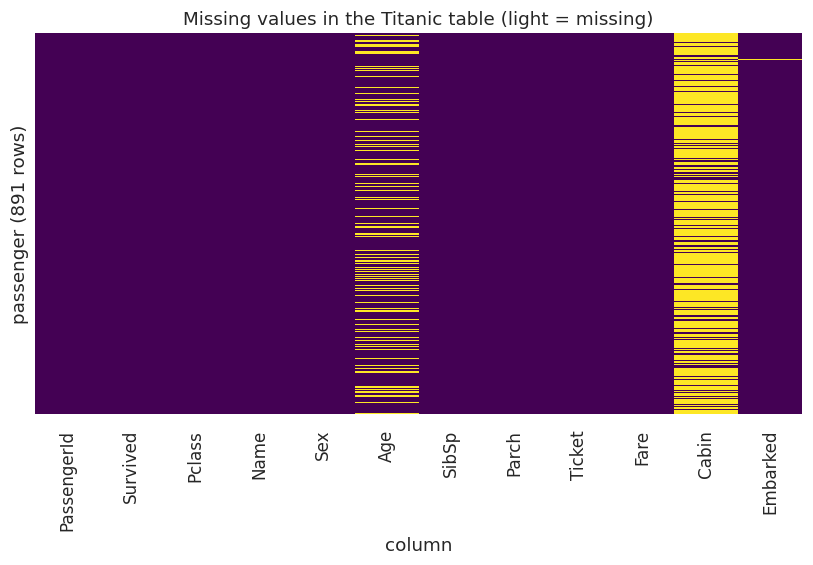

In [231]:
fig, ax = plt.subplots(figsize=(9, 4.5))
sns.heatmap(titanic.isna(), cbar=False, cmap="viridis", yticklabels=False, ax=ax)
ax.set_title("Missing values in the Titanic table (light = missing)")
ax.set_xlabel("column")
ax.set_ylabel("passenger (891 rows)")
plt.show()

`Cabin` is missing for most of the table in a solid block. `Age` is missing
in a scattered pattern. `Embarked` has two stripes you have to look for.
Three different shapes, and shortly three different explanations.

### 5.3 MCAR, MAR, MNAR

The standard vocabulary. It matters because it determines whether an
imputation can be honest.

- **MCAR** — missing completely at random. Whether a value is missing is
  independent of everything, observed or not. A tube broke in the lab.
  Dropping these rows loses precision but does not bias the result.
- **MAR** — missing at random, *given the observed data*. Whether a value
  is missing depends on other columns you have. You can model the
  missingness and impute sensibly.
- **MNAR** — missing not at random. Whether a value is missing depends on
  the missing value itself. Nobody reports an income they are ashamed of.
  No imputation from the observed data can fix this; the fact of
  missingness is itself data.

Test Titanic's `Cabin` against this scheme. If `Cabin` were MCAR, its
missingness would be unrelated to every other column:

In [232]:
titanic["cabin_missing"] = titanic["Cabin"].isna()

print("Proportion of Cabin missing, by passenger class:")
print(titanic.groupby("Pclass")["cabin_missing"].mean().round(4))
print()
print("Proportion of Cabin missing, by survival:")
print(titanic.groupby("Survived")["cabin_missing"].mean().round(4))

Proportion of Cabin missing, by passenger class:
Pclass
1   0.1852
2   0.9130
3   0.9756
Name: cabin_missing, dtype: float64

Proportion of Cabin missing, by survival:
Survived
0   0.8761
1   0.6023
Name: cabin_missing, dtype: float64


`Cabin` is missing for 19 % of first-class passengers and 98 % of
third-class passengers. **That is not random.** Missingness is strongly
predicted by `Pclass`, an observed column, which makes it MAR at best —
and quite plausibly MNAR, since the underlying reason is that cheaper
tickets did not have an assigned cabin recorded, so the value is missing
*because of what it would have been*.

The practical consequence: `cabin_missing` carries information. Discarding
`Cabin` throws away a usable signal; the standard move is to keep the
indicator even when the value itself is unrecoverable.

In [233]:
print("Survival rate when Cabin is recorded    :",
      round(titanic.loc[~titanic["cabin_missing"], "Survived"].mean(), 4))
print("Survival rate when Cabin is missing     :",
      round(titanic.loc[titanic["cabin_missing"], "Survived"].mean(), 4))

Survival rate when Cabin is recorded    : 0.6667
Survival rate when Cabin is missing     : 0.2999


67 % against 30 %. The *absence* of a value predicts the outcome better
than most present values do. This is what "missingness is a pattern, not a
nuisance" means in practice.

### 5.4 Four ways to fill `Age`, and four different distributions

`Age` is missing for 177 passengers, about 20 %. Here are the options the
drafts chose between without comparing them.

In [234]:
age = titanic["Age"]

strategies = {
    "dropna (177 rows lost)": age.dropna(),
    "fill with mean": age.fillna(age.mean()),
    "fill with median": age.fillna(age.median()),
    "fill with group median": age.fillna(titanic.groupby(["Pclass", "Sex"])["Age"].transform("median")),
}

summary = pd.DataFrame({
    name: {"n": s.count(), "mean": s.mean(), "median": s.median(), "std": s.std()}
    for name, s in strategies.items()
}).T
print(summary.round(4))

                              n    mean  median     std
dropna (177 rows lost) 714.0000 29.6991 28.0000 14.5265
fill with mean         891.0000 29.6991 29.6991 13.0020
fill with median       891.0000 29.3616 28.0000 13.0197
fill with group median 891.0000 29.1124 26.0000 13.3044


Read the `std` column. Filling 177 values with a single constant pulls 20 %
of the data onto one point, which **shrinks the standard deviation** from
14.53 to about 13.0. The mean is preserved by construction when you fill
with the mean — and preserving the mean while destroying the variance is
exactly the kind of damage that does not announce itself.

The group-wise median conditions on `Pclass` and `Sex`, so it fills each
passenger with a value drawn from people like them. It distorts the
distribution least.

See it rather than read it:

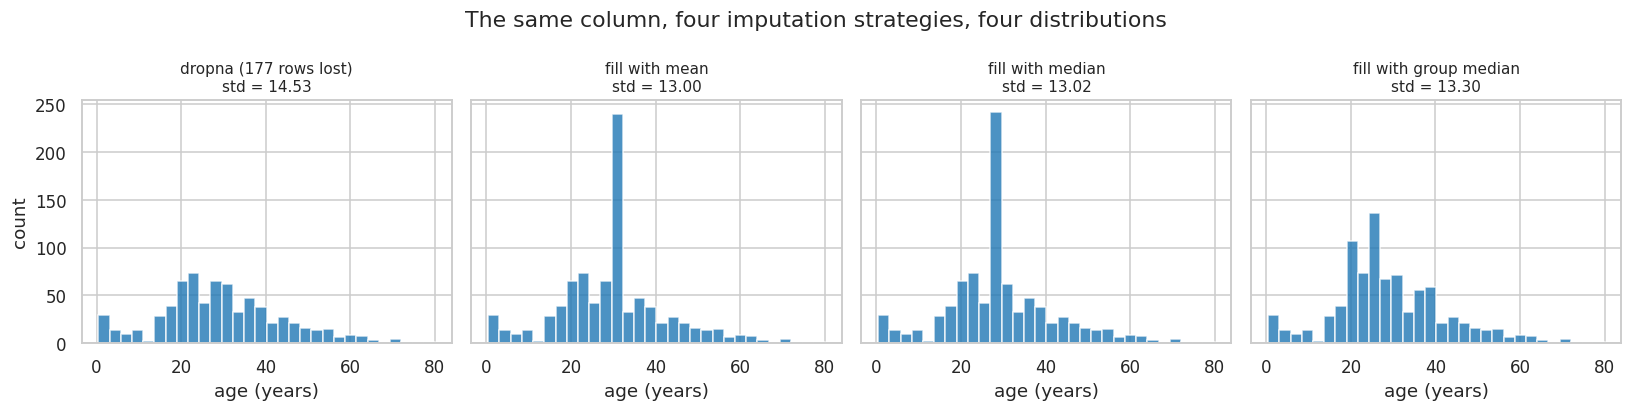

In [235]:
fig, axes = plt.subplots(1, 4, figsize=(15, 3.8), sharey=True, sharex=True)

for ax, (name, series) in zip(axes, strategies.items()):
    ax.hist(series, bins=30, alpha=0.8, color="tab:blue")
    ax.set_title(f"{name}\nstd = {series.std():.2f}", fontsize=10)
    ax.set_xlabel("age (years)")
axes[0].set_ylabel("count")

fig.suptitle("The same column, four imputation strategies, four distributions")
fig.tight_layout()
plt.show()

The spike in the two constant-fill panels is the 177 imputed passengers
stacked on one value. It is a fiction introduced by the analyst, and any
model trained afterwards will treat that spike as real structure.

`transform` in the group-median strategy is worth naming now: it returns a
Series **aligned to the original index**, one value per original row, which
is what makes it usable as a fill. §6.3 contrasts it with `agg`.

### 5.5 Filling `Embarked`

Two missing values out of 891. The draft filled them with `'S'`.

In [236]:
print(titanic["Embarked"].value_counts(dropna=False))
print()
print("The two passengers with no port of embarkation:")
print(titanic.loc[titanic["Embarked"].isna(), ["Name", "Pclass", "Fare", "Cabin"]])

Embarked
S      644
C      168
Q       77
NaN      2
Name: count, dtype: int64

The two passengers with no port of embarkation:
                                          Name  Pclass    Fare Cabin
61                         Icard, Miss. Amelie       1 80.0000   B28
829  Stone, Mrs. George Nelson (Martha Evelyn)       1 80.0000   B28


Filling with `'S'` is filling with the mode — 72 % of passengers boarded at
Southampton, so it is the most likely single answer. With two rows out of
891 the choice cannot change any downstream result, and that is the honest
justification: **the decision is defensible because it is small, not
because it is right.**

Contrast with `Age`, where the same reasoning applied to 20 % of the rows
would be indefensible. The size of the gap decides how much care the fill
deserves.

In [237]:
print("mode of Embarked:", titanic["Embarked"].mode()[0])
print("share of that mode:", round(titanic['Embarked'].value_counts(normalize=True).iloc[0], 4))
print("rows affected:", int(titanic['Embarked'].isna().sum()), "of", len(titanic))

mode of Embarked: S
share of that mode: 0.7244
rows affected: 2 of 891


## 6. Grouping: split, apply, combine

### 6.1 The pattern

`groupby` splits the table into groups by the values of a key, applies a
reduction to each group, and combines the results into a new object. The
draft's `df[['Sex','Age']].groupby('Sex').mean()` is one instance of it.

In [238]:
by_sex = titanic.groupby("Sex")["Age"].mean()

print(by_sex)
print()
print("type   :", type(by_sex).__name__)
print("index  :", list(by_sex.index), " <- the grouping key BECAME the index")
print("name   :", by_sex.name)

Sex
female   27.9157
male     30.7266
Name: Age, dtype: float64

type   : Series
index  : ['female', 'male']  <- the grouping key BECAME the index
name   : Age


### 6.2 What happened to the index

The grouping key is not a column of the result. It became the index. That
is why the draft's output looked different from the input and why the next
operation on it behaves differently — you can no longer select `Sex` as a
column, because there is no such column.

In [239]:
print("does the result have a 'Sex' column? ", "Sex" in by_sex.reset_index().columns)
print()
print("as_index=False keeps it as a column instead:")
print(titanic.groupby("Sex", as_index=False)["Age"].mean())
print()
print("reset_index() does the same thing after the fact:")
print(by_sex.reset_index())

does the result have a 'Sex' column?  True

as_index=False keeps it as a column instead:
      Sex     Age
0  female 27.9157
1    male 30.7266

reset_index() does the same thing after the fact:
      Sex     Age
0  female 27.9157
1    male 30.7266


Use `as_index=False` when the result is going to be merged, plotted or
written to a file, where a column is more convenient than an index. Use
the default when you want to look the answer up by key.

### 6.3 `agg` against `transform`

Two different shapes of answer, and the distinction matters.

- `agg` returns **one row per group**. It is a summary.
- `transform` returns **one row per original row**, with the group's value
  broadcast back to every member. It is a new column.

§5.4 already used `transform` to build the group-wise median fill; here is
why that was the only option.

In [240]:
grouped = titanic.groupby(["Pclass", "Sex"])["Age"]

print("agg      ->", grouped.median().shape, "rows: one per group")
print(grouped.median())
print()
print("transform ->", grouped.transform("median").shape, "rows: one per passenger")
print(grouped.transform("median").head(6))

agg      -> (6,) rows: one per group
Pclass  Sex   
1       female   35.0000
        male     40.0000
2       female   28.0000
        male     30.0000
3       female   21.5000
        male     25.0000
Name: Age, dtype: float64

transform -> (891,) rows: one per passenger
0   25.0000
1   35.0000
2   21.5000
3   35.0000
4   25.0000
5   25.0000
Name: Age, dtype: float64


`agg` gives six numbers, one per `(Pclass, Sex)` combination. `transform`
gives 891, each passenger labelled with their group's median. Only the
second can be assigned back as a column or used in `fillna`.

### 6.4 Several aggregations at once

`agg` takes a list of functions, or a dict mapping columns to functions.

In [241]:
summary = titanic.groupby("Pclass").agg(
    passengers=("PassengerId", "count"),
    survival_rate=("Survived", "mean"),
    median_age=("Age", "median"),
    mean_fare=("Fare", "mean"),
    max_fare=("Fare", "max"),
)
print(summary.round(4))

        passengers  survival_rate  median_age  mean_fare  max_fare
Pclass                                                            
1              216         0.6296     37.0000    84.1547  512.3292
2              184         0.4728     29.0000    20.6622   73.5000
3              491         0.2424     24.0000    13.6756   69.5500


That form — `new_name=(column, function)` — is named aggregation, and it is
worth preferring because the output column names are stated rather than
generated. The alternative produces a two-level column index that is
awkward to work with:

In [242]:
print(titanic.groupby("Pclass").agg({"Fare": ["mean", "max"], "Age": "median"}).round(3))
print()
print("column labels are now tuples:",
      list(titanic.groupby("Pclass").agg({"Fare": ["mean", "max"]}).columns))

          Fare              Age
          mean      max  median
Pclass                         
1      84.1550 512.3290 37.0000
2      20.6620  73.5000 29.0000
3      13.6760  69.5500 24.0000

column labels are now tuples: [('Fare', 'mean'), ('Fare', 'max')]


### 6.5 Grouping by more than one key

The result gets a `MultiIndex`, one level per key.

In [243]:
two_key = titanic.groupby(["Pclass", "Sex"])["Survived"].mean()

print(two_key.round(4))
print()
print("index levels:", two_key.index.names)
print()
print("the same numbers as a rectangle, which is usually easier to read:")
print(two_key.unstack().round(4))

Pclass  Sex   
1       female   0.9681
        male     0.3689
2       female   0.9211
        male     0.1574
3       female   0.5000
        male     0.1354
Name: Survived, dtype: float64

index levels: ['Pclass', 'Sex']

the same numbers as a rectangle, which is usually easier to read:
Sex     female   male
Pclass               
1       0.9681 0.3689
2       0.9211 0.1574
3       0.5000 0.1354


`unstack()` moves the innermost index level into the columns. The table it
produces is §11's Simpson's paradox in numbers, before it is a picture.

## 7. Reshaping, types and joins

### 7.1 Categories

A text column with few distinct values is a category, and saying so saves
memory and states an intent.

In [244]:
print("as object :", titanic["Sex"].memory_usage(deep=True), "bytes")
sex_category = titanic["Sex"].astype("category")
print("as category:", sex_category.memory_usage(deep=True), "bytes")
print()
print("categories:", list(sex_category.cat.categories))
print("stored as small integer codes:", sex_category.cat.codes.head(5).tolist())

as object : 47983 bytes
as category: 1239 bytes

categories: ['female', 'male']
stored as small integer codes: [1, 0, 0, 0, 1]


A categorical column stores each distinct value once and keeps an array of
small integer codes. Note that those codes exist *inside* the dtype and are
not a licence to feed them to a model as numbers — §12 is about exactly
that mistake.

### 7.2 Binning a continuous variable with `cut`

`cut` converts a number into a band. Binning discards information, so the
boundaries need a justification.

In [245]:
age_band = pd.cut(
    titanic["Age"],
    bins=[0, 12, 18, 35, 60, 100],
    labels=["child", "teen", "young adult", "adult", "senior"],
)

print(age_band.value_counts().sort_index())
print()
print("survival by age band:")
print(titanic.groupby(age_band, observed=True)["Survived"].mean().round(4))

Age
child           69
teen            70
young adult    358
adult          195
senior          22
Name: count, dtype: int64

survival by age band:
Age
child         0.5797
teen          0.4286
young adult   0.3827
adult         0.4000
senior        0.2273
Name: Survived, dtype: float64


Children survived at 58 % against an overall 38 %. The bands here are
conventional rather than derived, and a different set of boundaries would
give different numbers — which is the same caution as §8's bin count,
applied to a table instead of a chart.

### 7.3 `concat`, `merge`, `sort_values`, `rename`, `drop`

The routine reshaping vocabulary, in one cell each.

In [246]:
# concat: stack tables that share columns
top = titanic.head(3)[["Name", "Pclass", "Fare"]]
bottom = titanic.tail(3)[["Name", "Pclass", "Fare"]]
print("concat, 3 + 3 rows ->", pd.concat([top, bottom]).shape)
print(pd.concat([top, bottom]))

concat, 3 + 3 rows -> (6, 3)
                                                  Name  Pclass    Fare
0                              Braund, Mr. Owen Harris       3  7.2500
1    Cumings, Mrs. John Bradley (Florence Briggs Th...       1 71.2833
2                               Heikkinen, Miss. Laina       3  7.9250
888           Johnston, Miss. Catherine Helen "Carrie"       3 23.4500
889                              Behr, Mr. Karl Howell       1 30.0000
890                                Dooley, Mr. Patrick       3  7.7500


Note the index: `0, 1, 2, 888, 889, 890`. `concat` preserves the original
labels, so the result has a non-contiguous index. Pass
`ignore_index=True` when the old labels are meaningless.

In [247]:
# merge: join tables on a shared key, as in SQL
class_names = pd.DataFrame({
    "Pclass": [1, 2, 3],
    "class_name": ["first", "second", "third"],
})

merged = titanic[["Name", "Pclass", "Survived"]].merge(class_names, on="Pclass", how="left")
print(merged.head(4))
print()
print("rows before:", len(titanic), " after a left join:", len(merged))

                                                Name  Pclass  Survived class_name
0                            Braund, Mr. Owen Harris       3         0      third
1  Cumings, Mrs. John Bradley (Florence Briggs Th...       1         1      first
2                             Heikkinen, Miss. Laina       3         1      third
3       Futrelle, Mrs. Jacques Heath (Lily May Peel)       1         1      first

rows before: 891  after a left join: 891


Always check the row count after a merge. A left join that adds rows means
the key was not unique on the right-hand side, and that is almost always a
bug in the data rather than an intention.

In [248]:
# sort_values, rename, drop
tidy = (
    titanic[["Name", "Pclass", "Age", "Fare", "Survived"]]
    .rename(columns={"Pclass": "passenger_class", "Fare": "fare_paid"})
    .sort_values("fare_paid", ascending=False)
    .drop(columns=["Name"])
)
print(tidy.head(4))
print()
print("columns now:", list(tidy.columns))

     passenger_class     Age  fare_paid  Survived
679                1 36.0000   512.3292         1
258                1 35.0000   512.3292         1
737                1 35.0000   512.3292         1
88                 1 23.0000   263.0000         1

columns now: ['passenger_class', 'Age', 'fare_paid', 'Survived']


### 7.4 Tidy data

A table is **tidy** when each row is one observation, each column is one
variable, and each cell is one value. Most analysis tools, including every
scikit-learn estimator, assume tidy input, so the shape is not a matter of
taste.

Here is the same information in an untidy layout and the operation that
repairs it:

In [249]:
untidy = pd.DataFrame({
    "port": ["S", "C", "Q"],
    "survived_class1": [0.58, 0.69, 0.50],
    "survived_class2": [0.46, 0.53, 0.67],
    "survived_class3": [0.19, 0.24, 0.19],
})
print("untidy: the passenger class is spread across COLUMN NAMES")
print(untidy)

untidy: the passenger class is spread across COLUMN NAMES
  port  survived_class1  survived_class2  survived_class3
0    S           0.5800           0.4600           0.1900
1    C           0.6900           0.5300           0.2400
2    Q           0.5000           0.6700           0.1900


In [250]:
tidied = untidy.melt(id_vars="port", var_name="class_column", value_name="survival_rate")
tidied["passenger_class"] = tidied["class_column"].str.replace("survived_class", "").astype(int)
tidied = tidied.drop(columns="class_column")

print("tidy: one row per (port, class) observation")
print(tidied)

tidy: one row per (port, class) observation
  port  survival_rate  passenger_class
0    S         0.5800                1
1    C         0.6900                1
2    Q         0.5000                1
3    S         0.4600                2
4    C         0.5300                2
5    Q         0.6700                2
6    S         0.1900                3
7    C         0.2400                3
8    Q         0.1900                3


`melt` is the operation that turns columns into rows. Its inverse is
`pivot`. The untidy form is compact and good for reading; the tidy form is
what you compute with.

## 8. A table with dates and a mixed schema

Titanic is strings and floats. Real tables have dates, integer codes that
are not quantities, and measurements someone else transformed before
shipping. Load the bicycle rental data.

In [251]:
bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("shape:", bikes.shape)
print(bikes.dtypes)
bikes.head(3)

shape: (17379, 17)
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32


In [252]:
# Load bike sharing dataset

import pandas as pd

bikes = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/bike_sharing_hourly.csv"
)

print("shape:", bikes.shape)
print(bikes.dtypes)

bikes.head(3)

shape: (17379, 17)
instant         int64
dteday         object
season          int64
yr              int64
mnth            int64
hr              int64
holiday         int64
weekday         int64
workingday      int64
weathersit      int64
temp          float64
atemp         float64
hum           float64
windspeed     float64
casual          int64
registered      int64
cnt             int64
dtype: object


,instant,dteday,season,yr,mnth,hr,holiday,weekday,workingday,weathersit,temp,atemp,hum,windspeed,casual,registered,cnt
0,1,2011-01-01,1,0,1,0,0,6,0,1,0.2400,0.2879,0.8100,0.0000,3,13,16
1,2,2011-01-01,1,0,1,1,0,6,0,1,0.2200,0.2727,0.8000,0.0000,8,32,40
2,3,2011-01-01,1,0,1,2,0,6,0,1,0.2200,0.2727,0.8000,0.0000,5,27,32


### 8.1 Every column is numeric, and that is a lie

pandas reports `int64` for `season`, `weekday`, `weathersit` and `mnth`.
They are stored as integers and they are **not quantities**. `season = 4`
is not twice `season = 2`, and the mean of a season is meaningless.

In [253]:
print("pandas will happily compute this, and it means nothing:")
print("  mean season   :", round(bikes["season"].mean(), 4))
print("  mean weekday  :", round(bikes["weekday"].mean(), 4))
print()
print("whereas this is a real quantity:")
print("  mean rentals/h:", round(bikes["cnt"].mean(), 4))

pandas will happily compute this, and it means nothing:
  mean season   : 2.5016
  mean weekday  : 3.0037

whereas this is a real quantity:
  mean rentals/h: 189.4631


Nothing in the file marks the difference. You learn it from the data
dictionary — reproduced in `practice/datasets/README.md` so that you do not
have to leave this repository to read it — and then you encode it into the
types yourself:

In [254]:
categorical_columns = ["season", "yr", "mnth", "holiday", "weekday", "workingday", "weathersit"]
bikes[categorical_columns] = bikes[categorical_columns].astype("category")

print(bikes.dtypes.head(11))
print()
print("now a meaningless average is an error rather than a number:")
try:
    bikes["season"].mean()
except TypeError as exc:
    print("  TypeError:", str(exc)[:90])

instant          int64
dteday          object
season        category
yr            category
mnth          category
hr               int64
holiday       category
weekday       category
workingday    category
weathersit    category
temp           float64
dtype: object

now a meaningless average is an error rather than a number:
  TypeError: 'Categorical' with dtype category does not support reduction 'mean'


Declaring the type turned a silent wrong answer into a loud error. That is
the whole reason to bother.

### 8.2 Parsing a date

`dteday` arrived as text. Until it is parsed it sorts alphabetically, has
no notion of a month, and cannot be subtracted.

In [255]:
print("before parsing:", bikes["dteday"].dtype, "| example:", repr(bikes["dteday"].iloc[0]))

bikes["dteday"] = pd.to_datetime(bikes["dteday"])

print("after parsing :", bikes["dteday"].dtype)
print()
print("a date column unlocks its components:")
print("  year  ", bikes["dteday"].dt.year.unique())
print("  months", sorted(bikes["dteday"].dt.month.unique()))
print("  span  ", bikes["dteday"].min().date(), "to", bikes["dteday"].max().date())
print("  duration", (bikes["dteday"].max() - bikes["dteday"].min()).days, "days")

before parsing: object | example: '2011-01-01'
after parsing : datetime64[ns]

a date column unlocks its components:
  year   [2011 2012]
  months [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]
  span   2011-01-01 to 2012-12-31
  duration 730 days


### 8.3 Values someone else transformed

`temp`, `atemp`, `hum` and `windspeed` are not in physical units. The
provider divided each by its maximum before publishing. A column between 0
and 1 that is labelled "temperature" should always prompt the question.

In [256]:
print(bikes[["temp", "atemp", "hum", "windspeed"]].describe().round(4))

             temp       atemp         hum   windspeed
count 17,379.0000 17,379.0000 17,379.0000 17,379.0000
mean       0.4970      0.4758      0.6272      0.1901
std        0.1926      0.1719      0.1929      0.1223
min        0.0200      0.0000      0.0000      0.0000
25%        0.3400      0.3333      0.4800      0.1045
50%        0.5000      0.4848      0.6300      0.1940
75%        0.6600      0.6212      0.7800      0.2537
max        1.0000      1.0000      1.0000      0.8507


The documented divisors are 41 °C, 50 °C, 100 % and 67 km/h. Recovering the
physical units costs one line each and makes every later plot readable:

In [257]:
bikes["temp_celsius"] = bikes["temp"] * 41
bikes["humidity_percent"] = bikes["hum"] * 100
bikes["windspeed_kmh"] = bikes["windspeed"] * 67

print(bikes[["temp_celsius", "humidity_percent", "windspeed_kmh"]].describe().round(2))

       temp_celsius  humidity_percent  windspeed_kmh
count   17,379.0000       17,379.0000    17,379.0000
mean        20.3800           62.7200        12.7400
std          7.8900           19.2900         8.2000
min          0.8200            0.0000         0.0000
25%         13.9400           48.0000         7.0000
50%         20.5000           63.0000        13.0000
75%         27.0600           78.0000        17.0000
max         41.0000          100.0000        57.0000


A temperature range of 0.82 °C to 41 °C for Washington D.C. across two
years is plausible. That sanity check is only possible once the units are
back.

### 8.4 Grouping over time

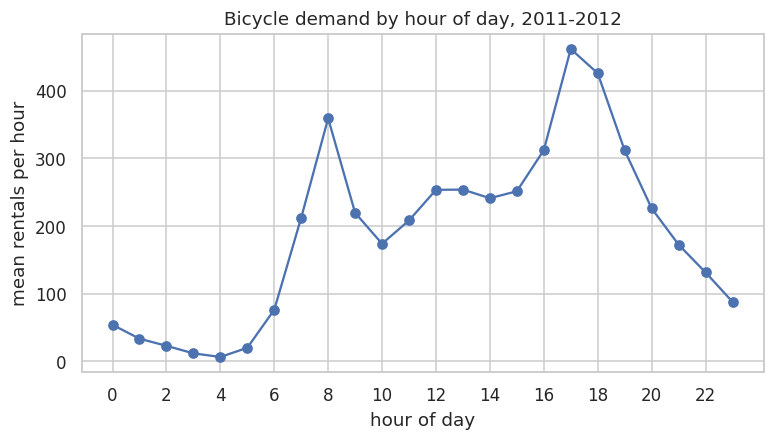

In [258]:
hourly_demand = bikes.groupby("hr", observed=True)["cnt"].mean()

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(hourly_demand.index, hourly_demand.values, marker="o")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean rentals per hour")
ax.set_title("Bicycle demand by hour of day, 2011-2012")
ax.set_xticks(range(0, 24, 2))
plt.show()

Two commuting peaks at 08:00 and 17:00-18:00. That shape is the reason
`hr` must be treated as a category and not as a number: the relationship
between hour and demand is not monotonic, so a model given `hr` as a
single numeric feature cannot represent it.

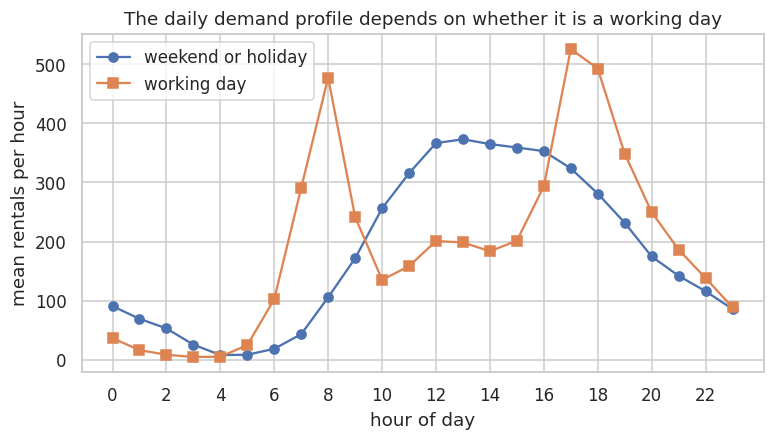

In [259]:
by_workingday = bikes.groupby(["workingday", "hr"], observed=True)["cnt"].mean().unstack(0)

fig, ax = plt.subplots(figsize=(8, 4))
ax.plot(by_workingday.index, by_workingday[0], marker="o", label="weekend or holiday")
ax.plot(by_workingday.index, by_workingday[1], marker="s", label="working day")
ax.set_xlabel("hour of day")
ax.set_ylabel("mean rentals per hour")
ax.set_title("The daily demand profile depends on whether it is a working day")
ax.set_xticks(range(0, 24, 2))
ax.legend()
plt.show()

Two completely different shapes. Pooling them, as the previous figure did,
produces an average profile that describes neither. This is the same
phenomenon as §11's Simpson's paradox: a conditioning variable changes the
answer, and averaging over it hides that.

## 9. Two matplotlib interfaces

Lesson 1 used `fig, ax = plt.subplots()` throughout without justifying it.
Here is the justification.

**The state machine.** `plt.plot(...)` draws on a figure matplotlib tracks
internally as "current". `plt.xlabel(...)` labels whichever axes is current
at that moment. It is short, and it is the style most tutorials use.

**The object-oriented interface.** `plt.subplots()` hands you the `Figure`
and the `Axes` as ordinary objects. You call methods on the object you
mean.

For one plot they are equivalent. The difference appears with two:

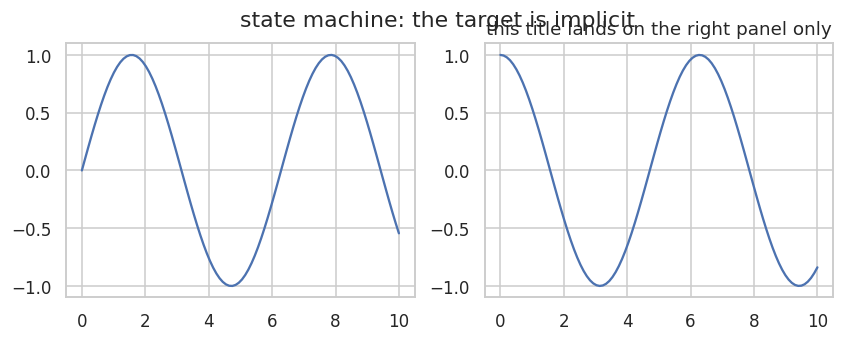

In [260]:
x = np.linspace(0, 10, 100)

# State machine: which axes does set_title apply to? The last one created.
plt.figure(figsize=(9, 3))
plt.subplot(1, 2, 1)
plt.plot(x, np.sin(x))
plt.subplot(1, 2, 2)
plt.plot(x, np.cos(x))
plt.title("this title lands on the right panel only")
plt.suptitle("state machine: the target is implicit")
plt.show()

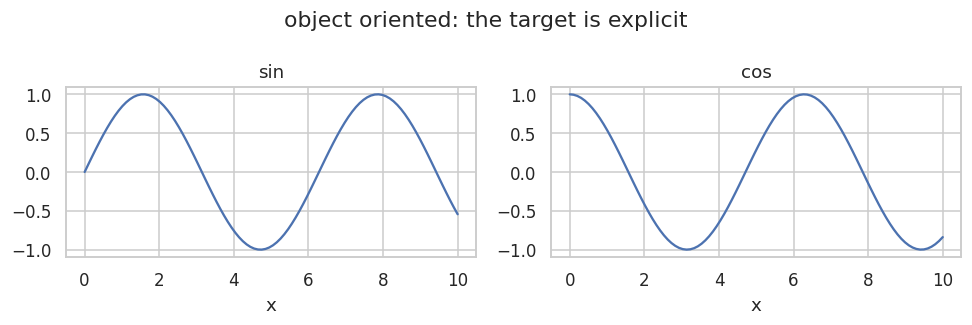

In [261]:
# Object oriented: the target is named every time.
fig, axes = plt.subplots(1, 2, figsize=(9, 3))
axes[0].plot(x, np.sin(x))
axes[0].set_title("sin")
axes[0].set_xlabel("x")
axes[1].plot(x, np.cos(x))
axes[1].set_title("cos")
axes[1].set_xlabel("x")
fig.suptitle("object oriented: the target is explicit")
fig.tight_layout()
plt.show()

In the first figure, `plt.title` attached to the right-hand panel because
that panel happened to be current. Nothing in the line says so. In a
notebook where cells are re-run out of order, "current" is not a property
you can reason about.

**Use the object-oriented form.** The state machine is fine for a throwaway
one-panel plot and it is a liability everywhere else.

Two more facilities worth naming, both used above: `sharey=True` forces
panels onto a common scale so that their heights are comparable, and
`fig.savefig(...)` writes the figure to a file.

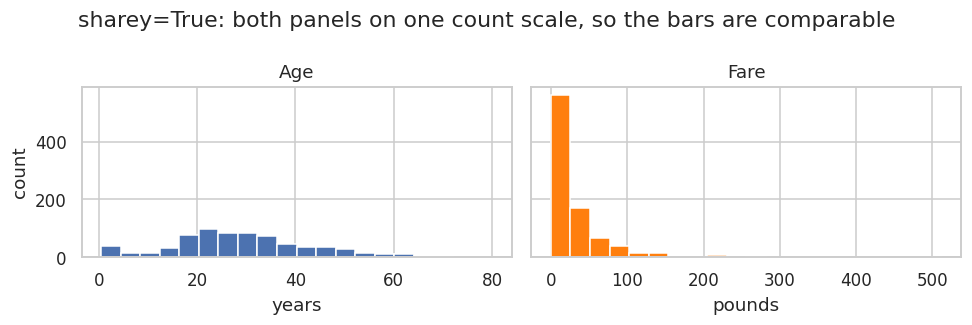

In [262]:
fig, axes = plt.subplots(1, 2, figsize=(9, 3), sharey=True)
axes[0].hist(titanic["Age"].dropna(), bins=20)
axes[0].set_title("Age")
axes[0].set_xlabel("years")
axes[0].set_ylabel("count")
axes[1].hist(titanic["Fare"], bins=20, color="tab:orange")
axes[1].set_title("Fare")
axes[1].set_xlabel("pounds")
fig.suptitle("sharey=True: both panels on one count scale, so the bars are comparable")
fig.tight_layout()
plt.show()

## 10. Choosing a chart from the question

A chart is not decoration and the choice is not aesthetic. Decide what
question you are asking, then read off the chart.

| The question | The chart |
|---|---|
| How is one numeric variable distributed? | histogram, KDE, boxplot |
| How does a count split across categories? | bar chart / `countplot` |
| Does a numeric variable differ between groups? | boxplot or violin, grouped |
| How do two numeric variables relate? | scatter |
| How do many numeric variables relate, pairwise? | correlation heatmap, pairplot |
| How does a quantity move over an ordered axis? | line |

Seaborn is a layer over matplotlib that takes a DataFrame and column names
instead of arrays. Every seaborn function draws on matplotlib `Axes`, and
you can mix the two freely.

### 10.1 Counts across categories

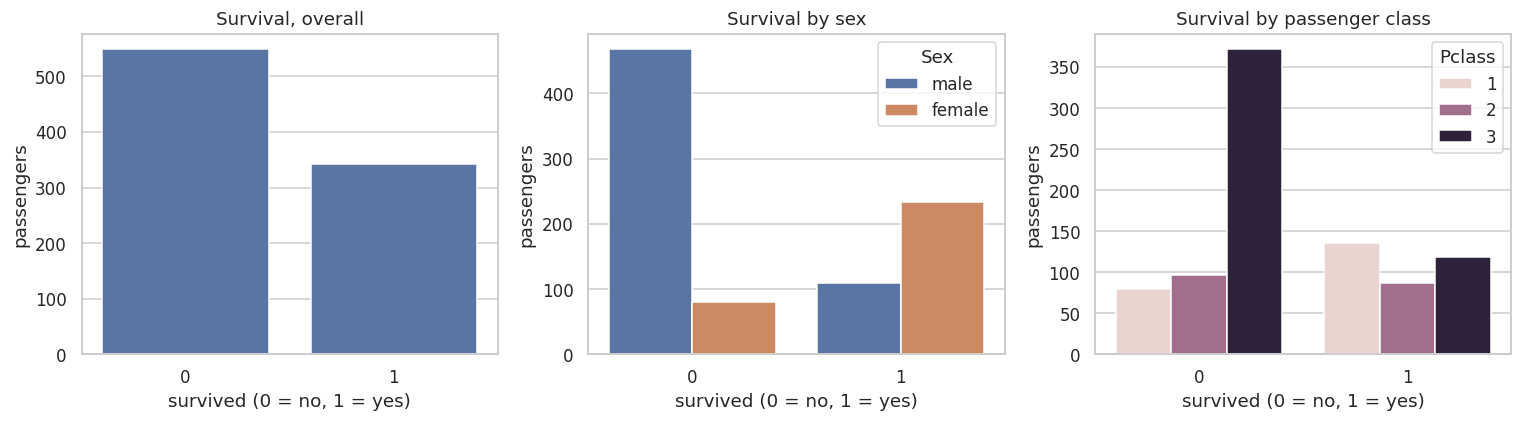

In [263]:
fig, axes = plt.subplots(1, 3, figsize=(14, 4))

sns.countplot(data=titanic, x="Survived", ax=axes[0])
axes[0].set_title("Survival, overall")

sns.countplot(data=titanic, x="Survived", hue="Sex", ax=axes[1])
axes[1].set_title("Survival by sex")

sns.countplot(data=titanic, x="Survived", hue="Pclass", ax=axes[2])
axes[2].set_title("Survival by passenger class")

for ax in axes:
    ax.set_xlabel("survived (0 = no, 1 = yes)")
    ax.set_ylabel("passengers")
fig.tight_layout()
plt.show()

`hue` is the conditioning variable: it splits every bar by a second
column. It is seaborn's most useful single argument, and it is the visual
form of the `groupby` in §6.5.

Read the middle panel carefully. Among the dead, men outnumber women
heavily; among the survivors, women outnumber men. That asymmetry is the
signal, and the raw counts understate it because there were more men
aboard. Proportions make it unambiguous:

In [264]:
print(titanic.groupby("Sex")["Survived"].agg(["count", "mean"]).round(4))

        count   mean
Sex                 
female    314 0.7420
male      577 0.1889


74 % against 19 %. When a `countplot` has unequal group sizes, always
compute the rate as well; the eye compares bar heights, not ratios.

### 10.2 Distributions, and the bin count as a decision

The default histogram is a choice someone else made for you.

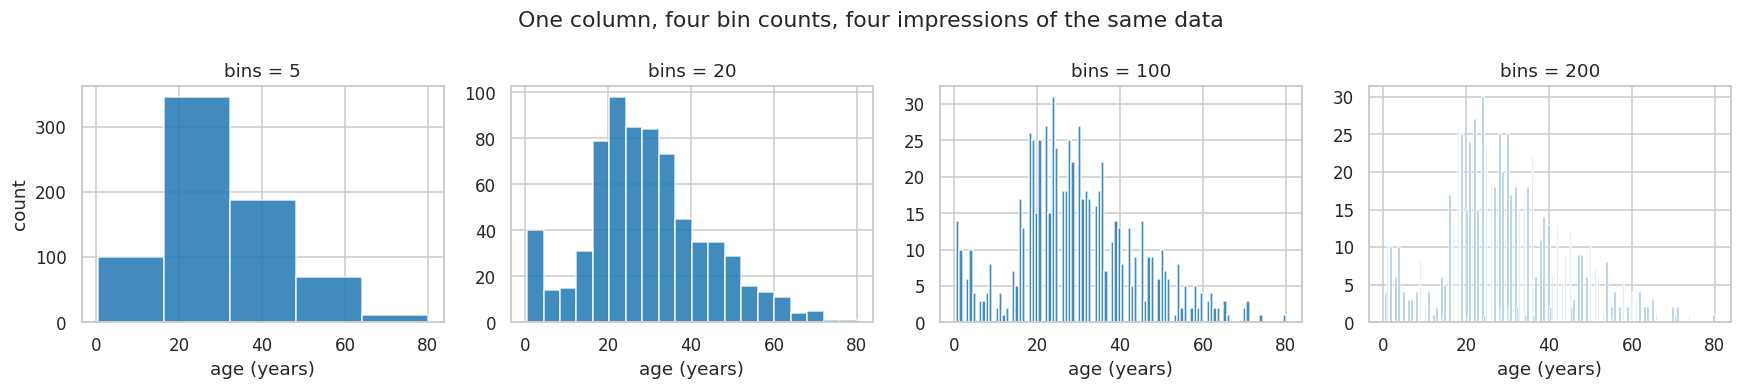

In [265]:
age_values = titanic["Age"].dropna()

fig, axes = plt.subplots(1, 4, figsize=(16, 3.6), sharey=False)
for ax, bins in zip(axes, [5, 20, 100, 200]):
    ax.hist(age_values, bins=bins, color="tab:blue", alpha=0.85)
    ax.set_title(f"bins = {bins}")
    ax.set_xlabel("age (years)")
axes[0].set_ylabel("count")
fig.suptitle("One column, four bin counts, four impressions of the same data")
fig.tight_layout()
plt.show()

At 5 bins the distribution looks like a single smooth hump. At 20 the
child peak below 10 appears, which is real. At 100 and 200 the bars break
into a comb of spikes at whole-numbered ages — an artifact of **age being
recorded as a round number** for most passengers, not a property of the
population.

So two of these four pictures would mislead a reader, in opposite
directions, and neither is wrong as a rendering. Check the artifact
directly:

In [266]:
whole_number_ages = (age_values % 1 == 0).mean()
print(f"ages recorded as a whole number: {whole_number_ages:.1%}")
print("most common recorded ages:")
print(age_values.value_counts().head(6))

ages recorded as a whole number: 96.5%
most common recorded ages:
Age
24.0000    30
22.0000    27
18.0000    26
28.0000    25
30.0000    25
19.0000    25
Name: count, dtype: int64


### 10.3 KDE and the bandwidth

A kernel density estimate replaces the bars with a smooth curve. It trades
the bin-count decision for a **bandwidth** decision, which is the same
decision wearing different clothes.

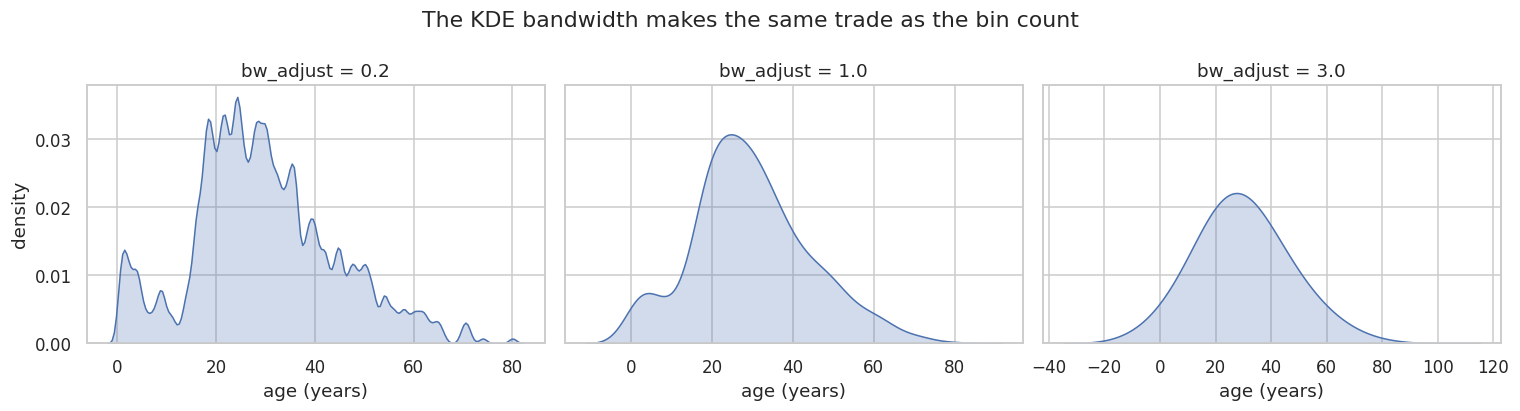

In [267]:
fig, axes = plt.subplots(1, 3, figsize=(14, 3.8), sharey=True)
for ax, adjust in zip(axes, [0.2, 1.0, 3.0]):
    sns.kdeplot(x=age_values, bw_adjust=adjust, fill=True, ax=ax)
    ax.set_title(f"bw_adjust = {adjust}")
    ax.set_xlabel("age (years)")
axes[0].set_ylabel("density")
fig.suptitle("The KDE bandwidth makes the same trade as the bin count")
fig.tight_layout()
plt.show()

A small bandwidth reproduces the rounding comb; a large one smooths the
child peak away entirely. A KDE also spreads density below zero, implying
negative ages, because the kernel does not know the variable is bounded.
A smooth curve looks more authoritative than a bar chart and carries
exactly the same uncertainty.

### 10.4 Boxplots, and a second definition of "outlier"

A boxplot draws the median, the quartiles, and whiskers at the most extreme
points **within 1.5 times the interquartile range** of the box. Points
beyond that are drawn individually.

Practice 1 §4.7 defined an outlier as more than 3 standard deviations from
the mean. This is a different definition, and the two disagree.

In [268]:
fare = titanic["Fare"]

q1, q3 = fare.quantile(0.25), fare.quantile(0.75)
iqr = q3 - q1
iqr_low, iqr_high = q1 - 1.5 * iqr, q3 + 1.5 * iqr
iqr_outliers = ((fare < iqr_low) | (fare > iqr_high)).sum()

mean, sd = fare.mean(), fare.std()
sigma_outliers = (np.abs(fare - mean) > 3 * sd).sum()

print(f"Q1 {q1:.2f}   Q3 {q3:.2f}   IQR {iqr:.2f}")
print(f"1.5 x IQR rule flags outside [{iqr_low:.2f}, {iqr_high:.2f}] -> {iqr_outliers} passengers")
print(f"3 sigma rule   flags outside [{mean - 3*sd:.2f}, {mean + 3*sd:.2f}] -> {sigma_outliers} passengers")

Q1 7.91   Q3 31.00   IQR 23.09
1.5 x IQR rule flags outside [-26.72, 65.63] -> 116 passengers
3 sigma rule   flags outside [-116.88, 181.28] -> 20 passengers


116 against 20, on the same column. Neither number is wrong; they are
answers to different questions.

- The **IQR rule** is built from quantiles, so it does not care about the
  shape of the distribution. On a skewed variable like `Fare` it flags the
  entire upper tail.
- The **3σ rule** assumes the data is roughly normal. `Fare` is not
  remotely normal, so the standard deviation is inflated by the very
  values you are trying to detect, and the threshold drifts outward to
  accommodate them.

On skewed data the 3σ rule under-reports for exactly the reason it was
applied.

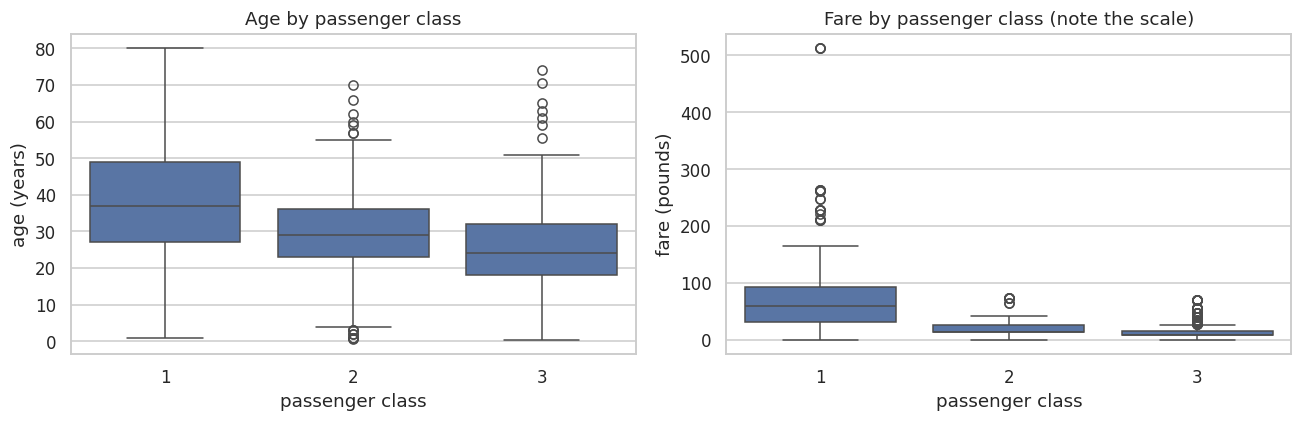

In [269]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

sns.boxplot(data=titanic, x="Pclass", y="Age", ax=axes[0])
axes[0].set_title("Age by passenger class")
axes[0].set_xlabel("passenger class")
axes[0].set_ylabel("age (years)")

sns.boxplot(data=titanic, x="Pclass", y="Fare", ax=axes[1])
axes[1].set_title("Fare by passenger class (note the scale)")
axes[1].set_xlabel("passenger class")
axes[1].set_ylabel("fare (pounds)")

fig.tight_layout()
plt.show()

### 10.5 Error, or signal?

The right-hand panel shows first-class fares reaching 512 pounds while the
median first-class fare is about 60. The IQR rule flags those as outliers.

**They are not errors.** They are the most expensive suites on the ship,
bought by the wealthiest passengers, who had the highest survival rate.
Removing them would delete precisely the effect under study.

In [270]:
extreme_fares = titanic[titanic["Fare"] > 300]
print(extreme_fares[["Name", "Pclass", "Fare", "Survived"]].to_string(index=False))
print()
print("all first class:", (extreme_fares["Pclass"] == 1).all())
print("survival among them:", round(extreme_fares["Survived"].mean(), 4),
      "against", round(titanic["Survived"].mean(), 4), "overall")

                              Name  Pclass     Fare  Survived
                  Ward, Miss. Anna       1 512.3292         1
Cardeza, Mr. Thomas Drake Martinez       1 512.3292         1
            Lesurer, Mr. Gustave J       1 512.3292         1

all first class: True
survival among them: 1.0 against 0.3838 overall


Contrast with the fares of zero:

In [271]:
zero_fare = titanic[titanic["Fare"] == 0]
print("passengers with a recorded fare of 0:", len(zero_fare))
print(zero_fare[["Name", "Pclass", "Ticket", "Survived"]].head(5).to_string(index=False))

passengers with a recorded fare of 0: 15
                           Name  Pclass Ticket  Survived
            Leonard, Mr. Lionel       3   LINE         0
          Harrison, Mr. William       1 112059         0
   Tornquist, Mr. William Henry       3   LINE         1
    Parkes, Mr. Francis "Frank"       2 239853         0
Johnson, Mr. William Cahoone Jr       3   LINE         0


Fifteen passengers with a fare of zero, spread across all three classes.
That is much more likely to be a recording convention for crew, guests or
unknown values than a real price. **An outlier at the bottom is suspicious
here while an outlier at the top is not**, and no statistical rule could
have told you that. Only the meaning of the column could.

The rule to carry forward: an outlier rule identifies candidates for
inspection. The decision to remove a point is a claim about the
measurement process and needs a reason from outside the data.

## 11. Relationships between variables

### 11.1 Correlation on a real feature set

Load the wine measurements: 178 wines, 13 physicochemical features, and a
`target` giving the cultivar.

In [272]:
wine = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/wine.csv"
)

print("shape:", wine.shape)
print("cultivars:", sorted(wine["target"].unique()), " counts:", wine["target"].value_counts().sort_index().tolist())
wine.head(3)

shape: (178, 14)
cultivars: [np.int64(0), np.int64(1), np.int64(2)]  counts: [59, 71, 48]


,alcohol,malic_acid,ash,alcalinity_of_ash,magnesium,total_phenols,flavanoids,nonflavanoid_phenols,proanthocyanins,color_intensity,hue,od280/od315_of_diluted_wines,proline,target
0,14.2300,1.7100,2.4300,15.6000,127.0000,2.8000,3.0600,0.2800,2.2900,5.6400,1.0400,3.9200,"1,065.0000",0
1,13.2000,1.7800,2.1400,11.2000,100.0000,2.6500,2.7600,0.2600,1.2800,4.3800,1.0500,3.4000,"1,050.0000",0
2,13.1600,2.3600,2.6700,18.6000,101.0000,2.8000,3.2400,0.3000,2.8100,5.6800,1.0300,3.1700,"1,185.0000",0


In [273]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
# wine = pd.read_csv("../datasets/wine.csv")
# print("shape:", wine.shape)
# print("cultivars:", sorted(wine["target"].unique()))
# wine.head(3)

In [274]:
wine.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 178 entries, 0 to 177
Data columns (total 14 columns):
 #   Column                        Non-Null Count  Dtype  
---  ------                        --------------  -----  
 0   alcohol                       178 non-null    float64
 1   malic_acid                    178 non-null    float64
 2   ash                           178 non-null    float64
 3   alcalinity_of_ash             178 non-null    float64
 4   magnesium                     178 non-null    float64
 5   total_phenols                 178 non-null    float64
 6   flavanoids                    178 non-null    float64
 7   nonflavanoid_phenols          178 non-null    float64
 8   proanthocyanins               178 non-null    float64
 9   color_intensity               178 non-null    float64
 10  hue                           178 non-null    float64
 11  od280/od315_of_diluted_wines  178 non-null    float64
 12  proline                       178 non-null    float64
 13  targe

No missing values and every column numeric — the opposite of Titanic, and
a reminder that "clean" is a property of a particular file rather than of
data in general.

The draft sliced to the first five features. Use all thirteen: the point of
a correlation matrix is the structure across the whole feature set.

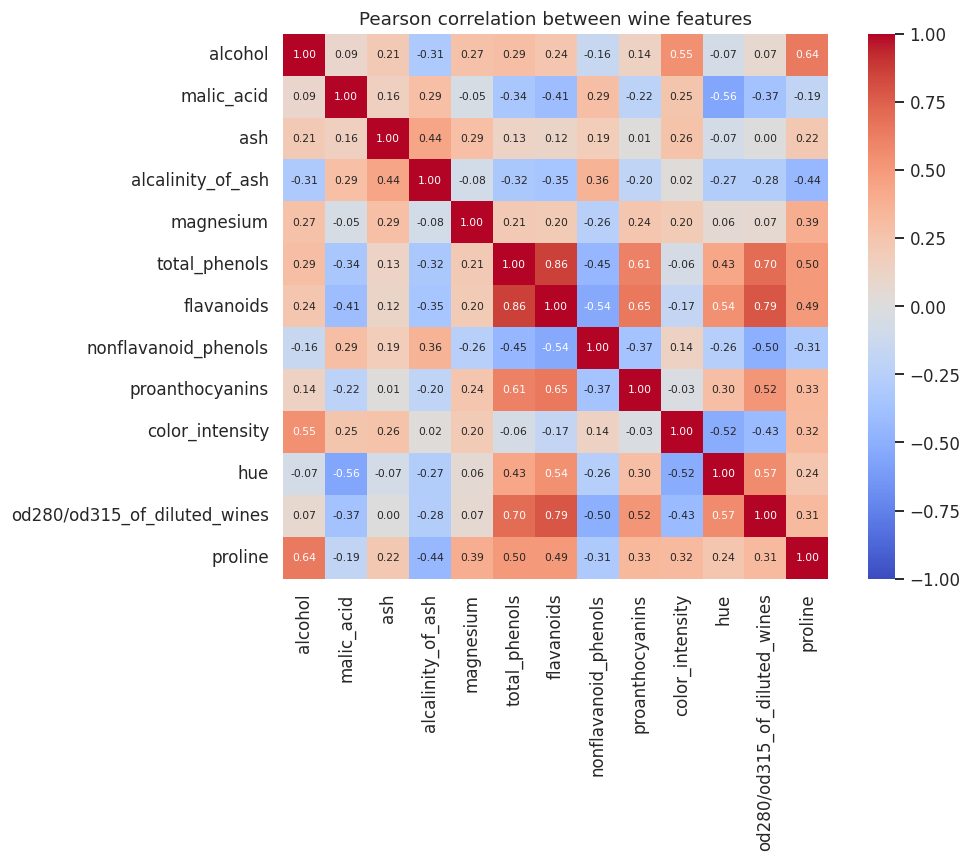

In [275]:
feature_columns = [c for c in wine.columns if c != "target"]
correlation = wine[feature_columns].corr()

fig, ax = plt.subplots(figsize=(10, 8))
sns.heatmap(correlation, cmap="coolwarm", annot=True, fmt=".2f",
            vmin=-1, vmax=1, center=0, square=True,
            annot_kws={"size": 7}, ax=ax)
ax.set_title("Pearson correlation between wine features")
fig.tight_layout()
plt.show()

Three arguments are doing real work. `center=0` puts the neutral colour at
zero correlation, so red and blue mean opposite signs rather than merely
"high" and "low". `vmin=-1, vmax=1` fixes the scale, so two heatmaps drawn
from different data are comparable. Without them the colours rescale to
whatever range happens to be present and the picture lies.

The strongest pair is `flavanoids` with `total_phenols` at 0.86 —
flavanoids are a subclass of phenols, so the correlation is close to a
definitional one rather than an empirical discovery.

In [276]:
pairs = (correlation.where(~np.eye(len(correlation), dtype=bool))
         .stack().sort_values())
print("most negative pairs:")
print(pairs.head(3).round(4))
print("\nmost positive pairs:")
print(pairs.tail(4).head(2).round(4))

most negative pairs:
malic_acid  hue                    -0.5613
hue         malic_acid             -0.5613
flavanoids  nonflavanoid_phenols   -0.5379
dtype: float64

most positive pairs:
flavanoids                    od280/od315_of_diluted_wines   0.7872
od280/od315_of_diluted_wines  flavanoids                     0.7872
dtype: float64


### 11.2 Pearson against Spearman

`corr()` defaults to the **Pearson** coefficient, which measures *linear*
association. **Spearman** correlates the ranks instead, so it measures any
*monotonic* association, linear or not.

They disagree exactly when the relationship is monotonic and curved:

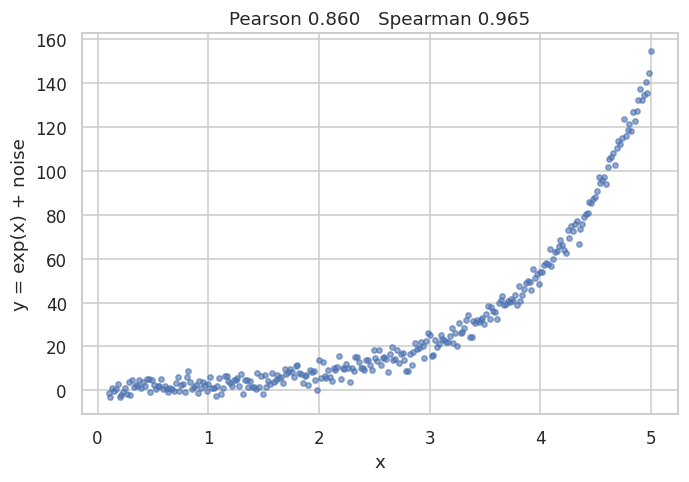

Pearson  (linear association)   : 0.8605
Spearman (monotonic association): 0.9653


In [277]:
curve_rng = np.random.default_rng(SEED)
x_mono = np.linspace(0.1, 5.0, 300)
y_mono = np.exp(x_mono) + curve_rng.normal(0, 3, 300)

pearson = np.corrcoef(x_mono, y_mono)[0, 1]
spearman = pd.Series(x_mono).corr(pd.Series(y_mono), method="spearman")

fig, ax = plt.subplots()
ax.scatter(x_mono, y_mono, s=12, alpha=0.6)
ax.set_xlabel("x")
ax.set_ylabel("y = exp(x) + noise")
ax.set_title(f"Pearson {pearson:.3f}   Spearman {spearman:.3f}")
plt.show()

print(f"Pearson  (linear association)   : {pearson:.4f}")
print(f"Spearman (monotonic association): {spearman:.4f}")

The relationship is perfectly monotonic — `y` rises whenever `x` rises —
so Spearman is near 1. Pearson is lower, because the relationship is not a
straight line and Pearson only measures how close to a straight line it
is.

Use Spearman when you care whether one variable tracks another, and
Pearson when you specifically care about a linear relationship, which is
what a linear model will try to fit. Reporting one while meaning the other
is a common and consequential error.

In [278]:
print("The same comparison on two wine features:")
for a, b in [("flavanoids", "total_phenols"), ("color_intensity", "hue")]:
    p = wine[a].corr(wine[b], method="pearson")
    s = wine[a].corr(wine[b], method="spearman")
    print(f"  {a:18} vs {b:16} Pearson {p:7.4f}   Spearman {s:7.4f}")

The same comparison on two wine features:
  flavanoids         vs total_phenols    Pearson  0.8646   Spearman  0.8794
  color_intensity    vs hue              Pearson -0.5218   Spearman -0.4185


### 11.3 Pairplot

A pairplot draws every pairwise scatter plus the marginal distribution on
the diagonal. It is the fastest way to see structure in a small feature
set, and it becomes unreadable past about six columns — 13 features would
be 169 panels.

Load Iris, which has four.

In [279]:
iris = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/iris.csv"
)

print("shape:", iris.shape)
print("species:", iris["Species"].unique().tolist())
iris.head(3)

shape: (150, 6)
species: ['Iris-setosa', 'Iris-versicolor', 'Iris-virginica']


,Id,SepalLengthCm,SepalWidthCm,PetalLengthCm,PetalWidthCm,Species
0,1,5.1000,3.5000,1.4000,0.2000,Iris-setosa
1,2,4.9000,3.0000,1.4000,0.2000,Iris-setosa
2,3,4.7000,3.2000,1.3000,0.2000,Iris-setosa


In [280]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
# iris = pd.read_csv("../datasets/iris.csv")

# print("shape:", iris.shape)
# print("species:", iris["Species"].unique().tolist())
# iris.head(3)

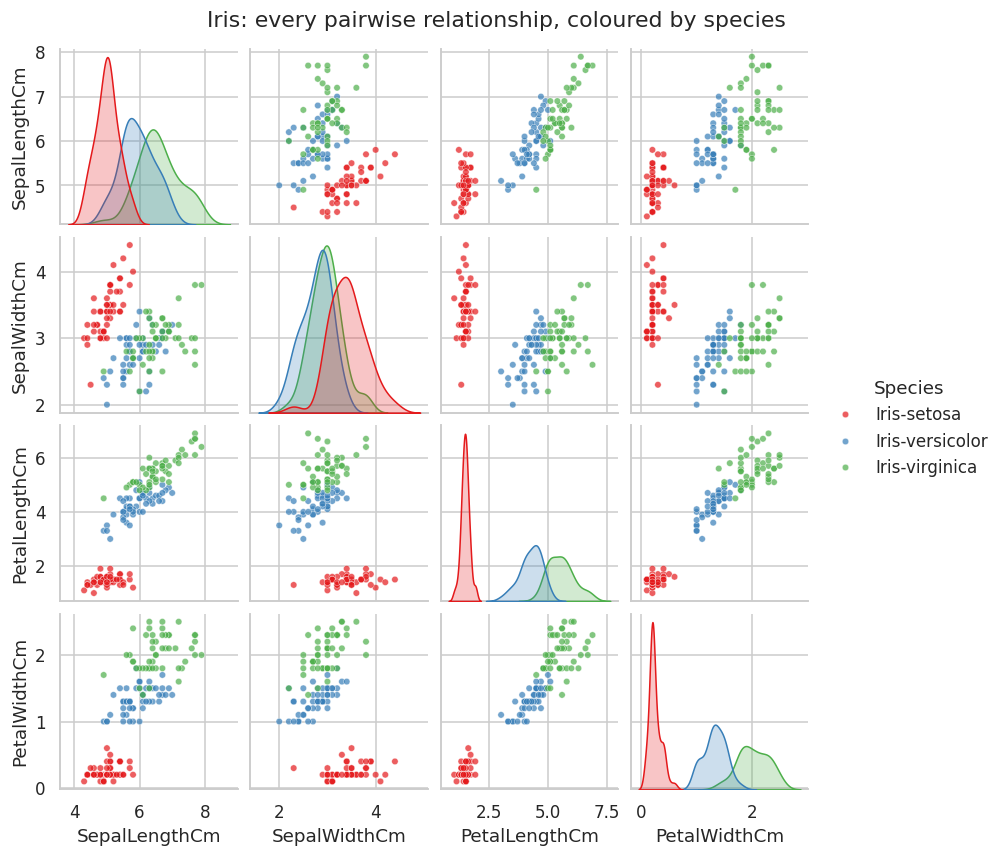

pairplot returns a PairGrid - a figure-level object, not an Axes


In [281]:
# 'Id' is a row number, not a measurement. Plotting it would be meaningless.
iris_features = iris.drop(columns=["Id"])

grid = sns.pairplot(iris_features, hue="Species", palette="Set1",
                    height=1.9, plot_kws={"s": 18, "alpha": 0.7})
grid.figure.suptitle("Iris: every pairwise relationship, coloured by species", y=1.02)
plt.show()

print("pairplot returns a", type(grid).__name__, "- a figure-level object, not an Axes")

Note the return type. Most seaborn functions are **Axes-level**: they take
`ax=` and draw into it, so they compose with `plt.subplots`. A few —
`pairplot`, `jointplot`, `catplot`, `lmplot` — are **figure-level**: they
create and own the whole figure, cannot be given an `ax`, and return a
grid object whose `.figure` attribute is how you reach the matplotlib
layer.

That is why `sns.countplot(..., ax=axes[0])` worked in §10.1 and
`sns.pairplot(..., ax=...)` would fail.

Reading the plot: setosa separates completely from the other two species
on petal length and petal width alone. Versicolor and virginica overlap
slightly. Practice 3 §8 fits a decision tree to exactly this data and the
tree's first split will be on a petal measurement, for the reason visible
here.

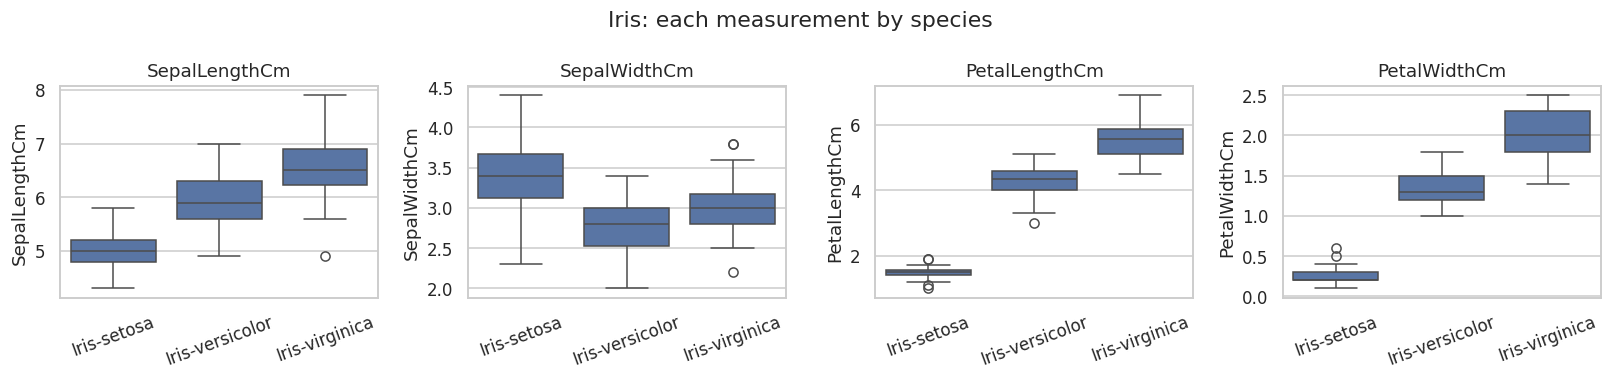

In [282]:
# The same conditioning applied per feature, as the draft's boxplot loop.
fig, axes = plt.subplots(1, 4, figsize=(15, 3.5))
for ax, column in zip(axes, [c for c in iris_features.columns if c != "Species"]):
    sns.boxplot(data=iris_features, x="Species", y=column, ax=ax)
    ax.set_title(column)
    ax.set_xlabel("")
    ax.tick_params(axis="x", rotation=20)
fig.suptitle("Iris: each measurement by species")
fig.tight_layout()
plt.show()

## 12. Correlation is not causation, and Simpson's paradox

### 12.1 The standard warning, and why it is not enough

"Correlation does not imply causation" is usually taught as a caution
about unmeasured confounders. The sharper and more disturbing version is
that a correlation can **reverse sign** when you condition on a variable
you already have.

This is Simpson's paradox, and Titanic contains a clean example.

In [283]:
overall = titanic.groupby("Sex")["Survived"].mean()
print("Survival rate by sex, pooled over all classes:")
print(overall.round(4))
print(f"\nadvantage to women: {overall['female'] - overall['male']:+.4f}")

Survival rate by sex, pooled over all classes:
Sex
female   0.7420
male     0.1889
Name: Survived, dtype: float64

advantage to women: +0.5531


Women survived at 74 %, men at 19 %. Now condition on passenger class.

In [284]:
by_class_sex = titanic.groupby(["Pclass", "Sex"])["Survived"].mean().unstack()
by_class_sex["difference"] = by_class_sex["female"] - by_class_sex["male"]

print(by_class_sex.round(4))

Sex     female   male  difference
Pclass                           
1       0.9681 0.3689      0.5992
2       0.9211 0.1574      0.7636
3       0.5000 0.1354      0.3646


The advantage holds within every class — it is largest in second class,
at 0.76, and smallest in third at 0.36 — so here the pooled answer and the
conditional answers agree in direction. That is the reassuring case. Now
take a different pair of variables:

In [285]:
# Does paying more associate with surviving? Pooled, and within each class.
pooled_corr = titanic["Fare"].corr(titanic["Survived"])
print(f"Pooled correlation between Fare and Survived: {pooled_corr:+.4f}")
print()
print("Within each passenger class separately:")
for pclass in sorted(titanic["Pclass"].unique()):
    subset = titanic[titanic["Pclass"] == pclass]
    print(f"  class {pclass}: {subset['Fare'].corr(subset['Survived']):+.4f}"
          f"   (n = {len(subset)}, mean fare {subset['Fare'].mean():6.2f})")

Pooled correlation between Fare and Survived: +0.2573

Within each passenger class separately:
  class 1: +0.1910   (n = 216, mean fare  84.15)
  class 2: +0.0986   (n = 184, mean fare  20.66)
  class 3: +0.0009   (n = 491, mean fare  13.68)


Pooled, fare correlates with survival at +0.26. Within each class it is
weaker — +0.19 in first, +0.10 in second, and +0.001 in third, where it
vanishes entirely. The pooled figure is largely produced by `Pclass`:
expensive tickets *are* first-class tickets, and first class is what
predicted survival. Paying more **within** your class bought much less
than the pooled number suggests, and in third class it bought nothing
measurable.

A model given `Fare` and not `Pclass` would attribute the class effect to
the fare. That is not a statistical error; it is a mis-stated question.

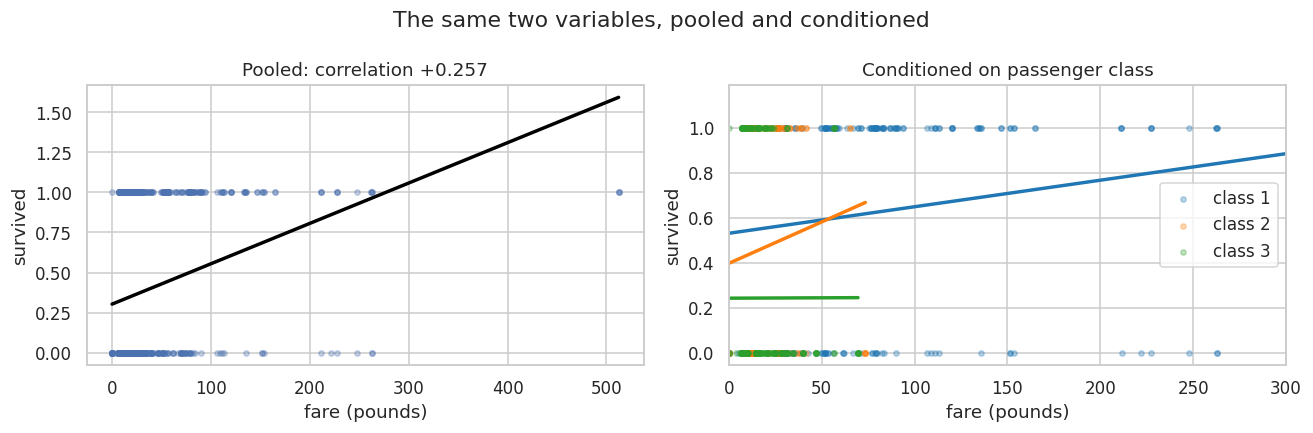

In [286]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# ci=None turns off seaborn's bootstrapped confidence band. The bootstrap
# draws unseeded random resamples, so leaving it on makes the figure differ
# between runs -- exactly the reproducibility failure of Lesson 1 section 4.1.
sns.regplot(data=titanic, x="Fare", y="Survived", logistic=False, ci=None,
            scatter_kws={"s": 12, "alpha": 0.3}, line_kws={"color": "black"}, ax=axes[0])
axes[0].set_title(f"Pooled: correlation {pooled_corr:+.3f}")
axes[0].set_xlabel("fare (pounds)")
axes[0].set_ylabel("survived")

for pclass, colour in zip([1, 2, 3], ["tab:blue", "tab:orange", "tab:green"]):
    subset = titanic[titanic["Pclass"] == pclass]
    sns.regplot(data=subset, x="Fare", y="Survived", logistic=False, ci=None,
                scatter_kws={"s": 12, "alpha": 0.3, "color": colour},
                line_kws={"color": colour}, label=f"class {pclass}", ax=axes[1])
axes[1].set_title("Conditioned on passenger class")
axes[1].set_xlabel("fare (pounds)")
axes[1].set_ylabel("survived")
axes[1].set_xlim(0, 300)
axes[1].legend()

fig.suptitle("The same two variables, pooled and conditioned")
fig.tight_layout()
plt.show()

The practical instruction: before reporting an association between two
variables, ask which third variable could be driving both, check whether
you have it, and if you do, condition on it and report both numbers.

## 13. Encoding categorical variables

A scikit-learn estimator takes numbers. Categories have to become numbers,
and **how** you do that determines what the model can learn.

### 13.1 The mistake the draft made

The draft applied `LabelEncoder` to `Sex` and to `Embarked` — that is, to
**features**.

In [287]:
from sklearn.preprocessing import LabelEncoder

embarked_filled = titanic["Embarked"].fillna("S")

encoder = LabelEncoder()
encoder.fit(embarked_filled)
embarked_label_encoded = encoder.transform(embarked_filled)

print("classes in order:", list(encoder.classes_))
print("mapping:", dict(zip(encoder.classes_, encoder.transform(encoder.classes_))))
print("first ten encoded values:", embarked_label_encoded[:10])

classes in order: ['C', 'Q', 'S']
mapping: {'C': np.int64(0), 'Q': np.int64(1), 'S': np.int64(2)}
first ten encoded values: [2 0 2 2 2 1 2 2 2 0]


`LabelEncoder` mapped Cherbourg to 0, Queenstown to 1 and Southampton to 2,
in alphabetical order. The three ports now sit on a number line.

**That number line does not exist.** Nothing makes Queenstown "between"
Cherbourg and Southampton. But every model that treats a feature as
numeric will act as though it does:

In [288]:
print("Distances the encoding has invented:")
print("  |C - Q| =", abs(0 - 1))
print("  |C - S| =", abs(0 - 2), " <- twice as far, for no reason")
print("  |Q - S| =", abs(1 - 2))
print()
print("A distance-based model such as KNN now believes Cherbourg is closer")
print("to Queenstown than to Southampton. Re-label the ports alphabetically")
print("differently and the geometry changes:")
alt = {"S": 0, "C": 1, "Q": 2}
print("  with S=0, C=1, Q=2:  |C - S| =", abs(1 - 0), " now they are adjacent")

Distances the encoding has invented:
  |C - Q| = 1
  |C - S| = 2  <- twice as far, for no reason
  |Q - S| = 1

A distance-based model such as KNN now believes Cherbourg is closer
to Queenstown than to Southampton. Re-label the ports alphabetically
differently and the geometry changes:
  with S=0, C=1, Q=2:  |C - S| = 1  now they are adjacent


The encoding is arbitrary, and the model's notion of similarity changes
with it. That is the definition of a feature that carries information the
data does not contain.

`LabelEncoder` is documented for **targets** — the `y` argument — where the
class labels are just names and no arithmetic is performed on them. Using
it on `X` is a category error that the API does not prevent.

### 13.2 One-hot encoding, which is correct for nominal features

Give each category its own binary column. No ordering is implied because
there is no shared axis.

In [289]:
one_hot = pd.get_dummies(embarked_filled, prefix="embarked", dtype=int)

print(one_hot.head(6))
print()
print("shape:", one_hot.shape, " one column per port")
print("every row sums to 1:", bool((one_hot.sum(axis=1) == 1).all()))

   embarked_C  embarked_Q  embarked_S
0           0           0           1
1           1           0           0
2           0           0           1
3           0           0           1
4           0           0           1
5           0           1           0

shape: (891, 3)  one column per port
every row sums to 1: True


Now every pair of ports is the same distance apart, which is the honest
representation of "three unordered labels".

In [290]:
from itertools import combinations

categories = ["C", "Q", "S"]
vectors = {c: one_hot.loc[embarked_filled == c].iloc[0].values for c in categories}

print("Euclidean distance between port encodings:")
print("  label encoding (invented ordering):")
label_map = {c: i for i, c in enumerate(encoder.classes_)}
for a, b in combinations(categories, 2):
    print(f"    {a} to {b}: {abs(label_map[a] - label_map[b]):.4f}")
print("  one-hot encoding (no ordering):")
for a, b in combinations(categories, 2):
    print(f"    {a} to {b}: {np.linalg.norm(vectors[a] - vectors[b]):.4f}")

Euclidean distance between port encodings:
  label encoding (invented ordering):
    C to Q: 1.0000
    C to S: 2.0000
    Q to S: 1.0000
  one-hot encoding (no ordering):
    C to Q: 1.4142
    C to S: 1.4142
    Q to S: 1.4142


Under one-hot every pair is exactly √2 apart. Under label encoding the
distances are 1, 1 and 2.

Practice 3 §10 fits KNN under both encodings and reports what it costs. The
answer there is worth previewing, because it is not the one this section
sets you up to expect: on `Embarked` the difference is negligible, and on
a 24-category column it is seven points of R². The size of the damage
depends on how many categories there are and how much the variable
matters — but you cannot know either in advance.

### 13.3 Ordinal encoding, which is correct when the order is real

`Pclass` is different. First, second and third class **are** ordered, and
the order is meaningful: second is between first and third in price, deck
height and survival rate. An integer encoding is appropriate here.

In [291]:
print("Survival rate by class, in class order:")
print(titanic.groupby("Pclass")["Survived"].mean().round(4))
print()
print("The order 1 < 2 < 3 corresponds to a real ordering, so encoding")
print("Pclass as 1, 2, 3 asserts something true about the world.")

Survival rate by class, in class order:
Pclass
1   0.6296
2   0.4728
3   0.2424
Name: Survived, dtype: float64

The order 1 < 2 < 3 corresponds to a real ordering, so encoding
Pclass as 1, 2, 3 asserts something true about the world.


The test is not the data type. It is whether the ordering you are about to
impose exists outside the encoding.

### 13.4 Two details worth knowing

**The dummy variable trap.** One-hot columns sum to 1 in every row, so any
one of them is a perfect linear function of the others. For a linear model
with an intercept this makes the design matrix singular. `drop_first=True`
removes one column and resolves it. Tree and distance based models are
unaffected.

In [292]:
full = pd.get_dummies(embarked_filled, prefix="embarked", dtype=int)
dropped = pd.get_dummies(embarked_filled, prefix="embarked", drop_first=True, dtype=int)

print("all categories :", list(full.columns), "->", full.shape[1], "columns")
print("drop_first=True:", list(dropped.columns), "->", dropped.shape[1], "columns")
print()
print("no information is lost: 0,0 in the two kept columns means the dropped one")

all categories : ['embarked_C', 'embarked_Q', 'embarked_S'] -> 3 columns
drop_first=True: ['embarked_Q', 'embarked_S'] -> 2 columns

no information is lost: 0,0 in the two kept columns means the dropped one


**Cardinality.** One-hot encoding a column with 681 distinct values, such
as `Ticket`, produces 681 columns — more features than rows. High
cardinality columns need a different treatment, or need to be dropped, or
need a derived feature such as "how many passengers share this ticket".

In [293]:
print("distinct values per object column:")
print(titanic[["Sex", "Embarked", "Cabin", "Ticket", "Name"]].nunique())
print()
print("one-hot on Ticket would produce", titanic["Ticket"].nunique(), "columns for", len(titanic), "rows")
print()
print("a derived feature instead, party size from shared tickets:")
titanic["ticket_party_size"] = titanic.groupby("Ticket")["Ticket"].transform("size")
print(titanic["ticket_party_size"].value_counts().sort_index().head(5))
print("\nsurvival by party size:")
print(titanic.groupby("ticket_party_size")["Survived"].mean().head(5).round(4))

distinct values per object column:
Sex           2
Embarked      3
Cabin       147
Ticket      681
Name        891
dtype: int64

one-hot on Ticket would produce 681 columns for 891 rows

a derived feature instead, party size from shared tickets:
ticket_party_size
1    547
2    188
3     63
4     44
5     10
Name: count, dtype: int64

survival by party size:
ticket_party_size
1   0.2980
2   0.5745
3   0.6984
4   0.5000
5   0.0000
Name: Survived, dtype: float64


## 14. Scaling

### 14.1 Instantiate, fit, transform

Every scikit-learn transformer has the same three steps, and keeping them
separate is what makes the next subsection's point visible.

- **instantiate** — create the object with its settings. Nothing has
  touched the data yet.
- **fit** — learn the parameters *from the data you pass*. For
  `StandardScaler`, the per-column mean and standard deviation.
- **transform** — apply those learned parameters.

In [294]:
from sklearn.preprocessing import StandardScaler, MinMaxScaler

column = np.array([[1], [5], [6], [7], [8], [10]], dtype=float)

standard = StandardScaler()          # 1. instantiate
standard.fit(column)                 # 2. fit: learn mean and scale
scaled = standard.transform(column)  # 3. transform: apply them

print("original :", column.ravel())
print("learned mean :", standard.mean_.round(4), " learned scale:", standard.scale_.round(4))
print("standardised :", scaled.ravel().round(4))
print()
print("mean after scaling:", round(float(scaled.mean()), 10),
      " std after scaling:", round(float(scaled.std()), 6))

original : [ 1.  5.  6.  7.  8. 10.]
learned mean : [6.1667]  learned scale: [2.7938]
standardised : [-1.8493 -0.4176 -0.0597  0.2983  0.6562  1.3721]

mean after scaling: -0.0  std after scaling: 1.0


`StandardScaler` subtracts the mean and divides by the standard deviation
— the operation written by hand with broadcasting in Practice 1 §3.7.
`MinMaxScaler` maps the observed range onto [0, 1] instead.

In [295]:
minmax = MinMaxScaler()
minmax.fit(column)
scaled_minmax = minmax.transform(column)

print("original      :", column.ravel())
print("min-max scaled:", scaled_minmax.ravel().round(4))
print()
print("data min:", minmax.data_min_, " data max:", minmax.data_max_)

original      : [ 1.  5.  6.  7.  8. 10.]
min-max scaled: [0.     0.4444 0.5556 0.6667 0.7778 1.    ]

data min: [1.]  data max: [10.]


**Which to use.** `StandardScaler` centres on the mean and is the default
choice; it does not bound the output and it is sensitive to extreme values
through the standard deviation. `MinMaxScaler` guarantees a [0, 1] range,
which some methods want, and is *more* sensitive to extremes — a single
large value compresses everything else toward zero.

In [296]:
with_extreme = np.array([[1], [5], [6], [7], [8], [1000]], dtype=float)

print("one extreme value added at the end:")
print("  standard:", StandardScaler().fit_transform(with_extreme).ravel().round(3))
print("  min-max :", MinMaxScaler().fit_transform(with_extreme).ravel().round(4))
print()
print("Under min-max the first five values are now crushed into [0, 0.007].")

one extreme value added at the end:
  standard: [-0.459 -0.448 -0.446 -0.443 -0.44   2.236]
  min-max : [0.    0.004 0.005 0.006 0.007 1.   ]

Under min-max the first five values are now crushed into [0, 0.007].


### 14.2 Which models care

Scaling matters for any method that measures **distance** or that
**penalises coefficient size**: KNN, SVM, k-means, PCA, ridge and lasso.
It does not matter for trees, which split one feature at a time on a
threshold and are unaffected by monotonic rescaling.

In [297]:
print("Two wine features on very different scales:")
print(wine[["proline", "hue"]].describe().loc[["mean", "std", "min", "max"]].round(3))
print()
span_proline = wine["proline"].max() - wine["proline"].min()
span_hue = wine["hue"].max() - wine["hue"].min()
print(f"proline spans {span_proline:.2f}, hue spans {span_hue:.2f}")
print(f"ratio: {span_proline / span_hue:.0f} to 1")
print()
print("In a Euclidean distance over these two raw columns, hue contributes")
print("essentially nothing. The distance is a measurement of proline alone.")

Two wine features on very different scales:
        proline    hue
mean   746.8930 0.9570
std    314.9070 0.2290
min    278.0000 0.4800
max  1,680.0000 1.7100

proline spans 1402.00, hue spans 1.23
ratio: 1140 to 1

In a Euclidean distance over these two raw columns, hue contributes
essentially nothing. The distance is a measurement of proline alone.


### 14.3 Fit on training data only

This is the part the drafts got wrong, and it is the most important
sentence in this section.

**A scaler is fitted on the training set and only on the training set.**
The test set is transformed with the training set's parameters. Fitting on
everything lets information from the test set — its mean, its spread —
influence the training data, which is called **leakage**, and it makes the
reported score optimistic.

In [298]:
from sklearn.model_selection import train_test_split

X_wine = wine[feature_columns].values
y_wine = wine["target"].values

X_train, X_test, y_train, y_test = train_test_split(
    X_wine, y_wine, test_size=0.3, random_state=SEED, stratify=y_wine
)

# CORRECT: learn the parameters from the training set alone.
correct_scaler = StandardScaler()
correct_scaler.fit(X_train)
X_train_ok = correct_scaler.transform(X_train)
X_test_ok = correct_scaler.transform(X_test)

# WRONG: learn them from everything, including the test set.
leaky_scaler = StandardScaler()
leaky_scaler.fit(X_wine)
X_test_leaky = leaky_scaler.transform(X_test)

print("Scaler means differ because they were fitted on different data:")
print("  fitted on train only:", correct_scaler.mean_[:4].round(4))
print("  fitted on everything:", leaky_scaler.mean_[:4].round(4))
print()
print("Correctly scaled test set does NOT have mean 0 or std 1, and should not:")
print("  test mean (correct):", X_test_ok.mean(axis=0)[:4].round(4))
print("  test std  (correct):", X_test_ok.std(axis=0)[:4].round(4))
print()
print("The leaked version looks 'cleaner', which is exactly the problem:")
print("  test mean (leaked) :", X_test_leaky.mean(axis=0)[:4].round(4))

Scaler means differ because they were fitted on different data:
  fitted on train only: [13.0089  2.3275  2.369  19.5476]
  fitted on everything: [13.0006  2.3363  2.3665 19.4949]

Correctly scaled test set does NOT have mean 0 or std 1, and should not:
  test mean (correct): [-0.0324  0.0259 -0.0291 -0.0526]
  test std  (correct): [0.8749 0.9652 0.9717 1.0321]

The leaked version looks 'cleaner', which is exactly the problem:
  test mean (leaked) : [-0.0234  0.0182 -0.0204 -0.0363]


Look at what distinguishes them. Under the correct procedure the test set
does **not** have mean 0 — it has whatever mean it has, measured on a
scale defined by the training data. Under the leaked procedure it is
centred, because its own values helped define the centre.

The leaked version looks tidier, and that tidiness is the symptom. At
prediction time you will have one new observation and no test-set
statistics to fit on, so the leaked procedure cannot be reproduced in
production — which means the score it reports is not a score for anything
you can deploy.

`fit_transform` is `fit` followed by `transform` in one call. Use it on
the training set; never on the test set.

In [299]:
print("The idiom, in three lines:")
print("  X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform")
print("  X_test_scaled  = scaler.transform(X_test)        # transform ONLY")
print()
X_train_scaled = StandardScaler().fit(X_train).transform(X_train)
print("verification that fit_transform and fit+transform agree:",
      np.allclose(StandardScaler().fit_transform(X_train), X_train_scaled))

The idiom, in three lines:
  X_train_scaled = scaler.fit_transform(X_train)   # fit AND transform
  X_test_scaled  = scaler.transform(X_test)        # transform ONLY

verification that fit_transform and fit+transform agree: True


Practice 3 §6 shows that even this is not sufficient once cross-validation
is involved, and replaces it with a `Pipeline`. The rule generalises: the
scaler must be fitted inside whatever loop defines "training data".

## 15. Dimensionality reduction

### 15.1 A genuinely high-dimensional dataset

784 features per row: a 28 by 28 grayscale image of a handwritten digit,
flattened. 1500 rows, 150 of each digit.

In [300]:
mnist = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/mnist_sample.csv"
)

print("shape:", mnist.shape)
print("label counts:", mnist["label"].value_counts().sort_index().tolist())
print("first five column names:", list(mnist.columns[:5]))
print("pixel value range:", mnist.iloc[:, 1:].values.min(), "to", mnist.iloc[:, 1:].values.max())

shape: (1500, 785)
label counts: [150, 150, 150, 150, 150, 150, 150, 150, 150, 150]
first five column names: ['label', 'p0_0', 'p0_1', 'p0_2', 'p0_3']
pixel value range: 0 to 255


In [301]:
# LOCAL ALTERNATIVE. Run EITHER this cell OR the one above, not both.
# Above reads over the network and is what Colab needs. This one reads
# the same files from your checkout, for the dev-env container. The
# data is identical; only the address differs.
# mnist = pd.read_csv("../datasets/mnist_sample.csv")

# print("shape:", mnist.shape)
# print("label counts:", mnist["label"].value_counts().sort_index().tolist())
# print("first five column names:", list(mnist.columns[:5]))
# print("pixel value range:", mnist.iloc[:, 1:].values.min(), "to", mnist.iloc[:, 1:].values.max())

The column names encode the geometry: `p<row>_<col>`. So the 784 pixel
columns can be folded back into a 28 by 28 image, which is what makes this
dataset legible in a way that an anonymous wide table is not.

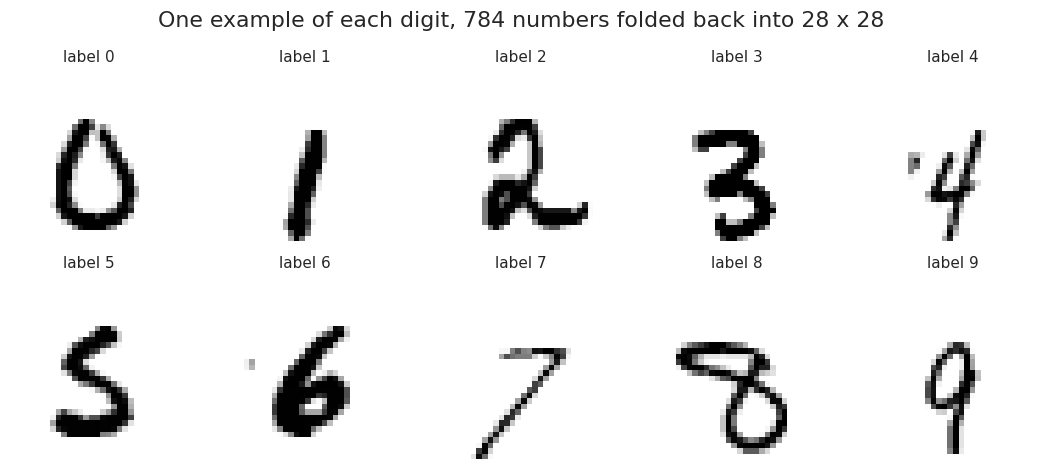

In [302]:
pixels = mnist.drop(columns="label").values
labels = mnist["label"].values

fig, axes = plt.subplots(2, 5, figsize=(10, 4.4))
for digit, ax in zip(range(10), axes.ravel()):
    first = np.flatnonzero(labels == digit)[0]
    ax.matshow(pixels[first].reshape(28, 28), cmap="gray_r")
    ax.set_title(f"label {digit}", fontsize=10)
    ax.axis("off")
fig.suptitle("One example of each digit, 784 numbers folded back into 28 x 28")
fig.tight_layout()
plt.show()

### 15.2 PCA, and why standardising comes first

Principal component analysis finds the directions along which the data
varies most, and re-expresses every point in terms of those directions.
The first component is the direction of maximum variance, the second is
the direction of maximum remaining variance perpendicular to the first,
and so on.

Because it is driven by variance, PCA is **scale dependent**: a feature
measured in millimetres will dominate the same feature measured in metres.
Standardise first, unless every feature is already in the same units.

Pixels are all in the same unit — intensity from 0 to 255 — so here
centring is essential and rescaling is optional. Do it on the wine data,
where the units genuinely differ, to make the point.

In [303]:
from sklearn.decomposition import PCA

# Wine, unscaled: proline (range ~1400) will dominate.
pca_unscaled = PCA().fit(X_wine)
pca_scaled = PCA().fit(StandardScaler().fit_transform(X_wine))

print("Variance explained by the first component:")
print(f"  without standardising: {pca_unscaled.explained_variance_ratio_[0]:.4%}")
print(f"  after standardising  : {pca_scaled.explained_variance_ratio_[0]:.4%}")
print()
print("Unscaled, the first component is almost entirely one feature:")
loading = pd.Series(np.abs(pca_unscaled.components_[0]), index=feature_columns)
print(loading.sort_values(ascending=False).head(3).round(4))

Variance explained by the first component:
  without standardising: 99.8091%
  after standardising  : 36.1988%

Unscaled, the first component is almost entirely one feature:
proline             0.9998
magnesium           0.0179
alcalinity_of_ash   0.0047
dtype: float64


Without standardising, the first component explains 99.8 % of the variance
and is essentially the `proline` axis. PCA has "discovered" that the
feature with the largest numbers has the largest numbers. After
standardising, the first component explains 36 % and is a genuine
combination of correlated measurements.

### 15.3 Explained variance, and how many components to keep

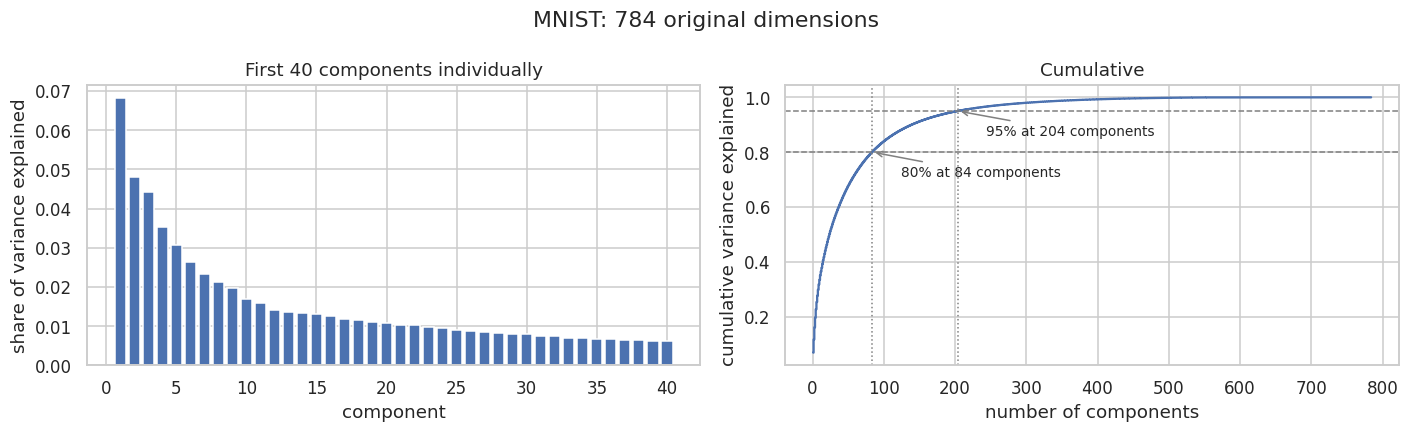

50% of the variance needs  24 of 784 components
80% of the variance needs  84 of 784 components
95% of the variance needs 204 of 784 components
99% of the variance needs 371 of 784 components


In [304]:
mnist_scaled = StandardScaler().fit_transform(pixels)
pca_mnist = PCA(random_state=SEED).fit(mnist_scaled)

ratios = pca_mnist.explained_variance_ratio_
cumulative = np.cumsum(ratios)

fig, axes = plt.subplots(1, 2, figsize=(13, 4))

axes[0].bar(range(1, 41), ratios[:40])
axes[0].set_xlabel("component")
axes[0].set_ylabel("share of variance explained")
axes[0].set_title("First 40 components individually")

axes[1].step(range(1, len(cumulative) + 1), cumulative, where="mid")
for threshold in (0.80, 0.95):
    n_needed = int(np.searchsorted(cumulative, threshold) + 1)
    axes[1].axhline(threshold, color="grey", linestyle="--", linewidth=1)
    axes[1].axvline(n_needed, color="grey", linestyle=":", linewidth=1)
    axes[1].annotate(f"{threshold:.0%} at {n_needed} components",
                     xy=(n_needed, threshold), xytext=(n_needed + 40, threshold - 0.09),
                     fontsize=9, arrowprops={"arrowstyle": "->", "color": "grey"})
axes[1].set_xlabel("number of components")
axes[1].set_ylabel("cumulative variance explained")
axes[1].set_title("Cumulative")

fig.suptitle("MNIST: 784 original dimensions")
fig.tight_layout()
plt.show()

for threshold in (0.50, 0.80, 0.95, 0.99):
    print(f"{threshold:.0%} of the variance needs "
          f"{int(np.searchsorted(cumulative, threshold) + 1):3d} of 784 components")

784 dimensions, and 95 % of the variance lives in a few hundred of them.
That redundancy is what dimensionality reduction exploits, and it exists
because neighbouring pixels in an image are strongly correlated.

There is no correct number of components. The three usual rules are: keep
enough for a stated share of variance (95 % is conventional and arbitrary);
keep as many as the elbow in the left-hand plot suggests; or treat it as a
hyperparameter and tune it against the task, which Practice 3 §6 shows how
to do.

### 15.4 What a component is

Each component is a **linear combination of all 784 original pixels**,
with a weight per pixel. For image data those weights can be folded back
into a picture.

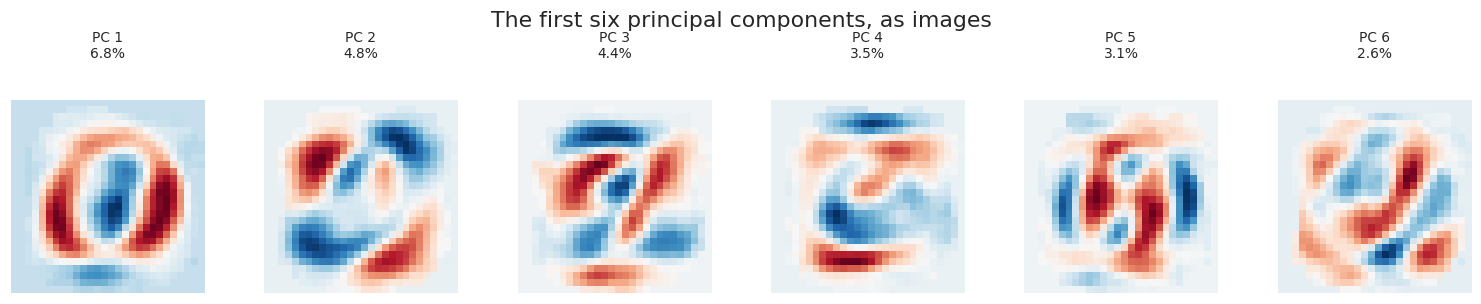

In [305]:
fig, axes = plt.subplots(1, 6, figsize=(14, 2.8))
for i, ax in enumerate(axes):
    ax.matshow(pca_mnist.components_[i].reshape(28, 28), cmap="RdBu_r")
    ax.set_title(f"PC {i + 1}\n{ratios[i]:.1%}", fontsize=9)
    ax.axis("off")
fig.suptitle("The first six principal components, as images")
fig.tight_layout()
plt.show()

These are not digits. They are the patterns of light and dark that best
distinguish digits from one another, and every digit in the dataset is
approximated by a weighted sum of them.

This is the interpretability cost. A model fitted on principal components
is fitted on quantities like "0.03 times pixel (4,7) plus 0.11 times pixel
(4,8) minus ...", and a coefficient on that has no meaning you can report
to a domain expert. Reducing dimension buys speed and noise suppression
and spends interpretability.

### 15.5 A two-dimensional PCA projection

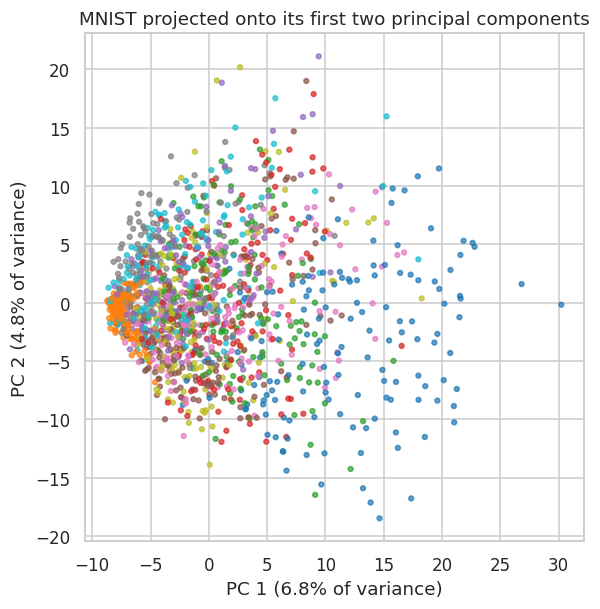

these two components carry 11.6% of the total variance


In [306]:
pca_2d = PCA(n_components=2, random_state=SEED)
mnist_pca_2d = pca_2d.fit_transform(mnist_scaled)

fig, ax = plt.subplots(figsize=(7.5, 6))
scatter = ax.scatter(mnist_pca_2d[:, 0], mnist_pca_2d[:, 1], c=labels,
                     cmap="tab10", s=10, alpha=0.7)
ax.set_xlabel(f"PC 1 ({pca_2d.explained_variance_ratio_[0]:.1%} of variance)")
ax.set_ylabel(f"PC 2 ({pca_2d.explained_variance_ratio_[1]:.1%} of variance)")
ax.set_title("MNIST projected onto its first two principal components")
ax.set_aspect("equal")
legend = ax.legend(*scatter.legend_elements(), title="digit",
                   loc="center left", bbox_to_anchor=(1.02, 0.5))
ax.add_artist(legend)
plt.show()

print(f"these two components carry {pca_2d.explained_variance_ratio_.sum():.1%} of the total variance")

`bbox_to_anchor=(1.02, 0.5)` places the legend outside the axes, which is
the only sensible option when the data fills the plotting area.

Zeros and ones separate; the rest overlap heavily. That is expected: two
linear directions carrying about 10 % of the variance cannot be expected to
untangle ten classes. PCA is constrained to linear projections, and the
structure that distinguishes a 4 from a 9 is not linear.

### 15.6 t-SNE

t-SNE is a nonlinear method designed specifically for visualisation. It
tries to place points in two dimensions so that **local neighbourhoods**
are preserved: points near each other in 784 dimensions end up near each
other on the page.

Standard practice is to reduce with PCA first — it removes noise and makes
t-SNE much faster — and then run t-SNE on the result.

In [307]:
from sklearn.manifold import TSNE

# PCA to 50 dimensions first: standard practice, and it keeps this cell
# inside the practice notebook's runtime budget. On the full 784 columns this takes
# several times longer for a visually similar result.
pca_50 = PCA(n_components=50, random_state=SEED).fit_transform(mnist_scaled)
print(f"reduced to {pca_50.shape[1]} dimensions, carrying "
      f"{cumulative[49]:.1%} of the variance, before running t-SNE")

tsne = TSNE(n_components=2, perplexity=30, random_state=SEED, init="pca")
mnist_tsne = tsne.fit_transform(pca_50)
print("t-SNE output shape:", mnist_tsne.shape)

reduced to 50 dimensions, carrying 67.6% of the variance, before running t-SNE
t-SNE output shape: (1500, 2)


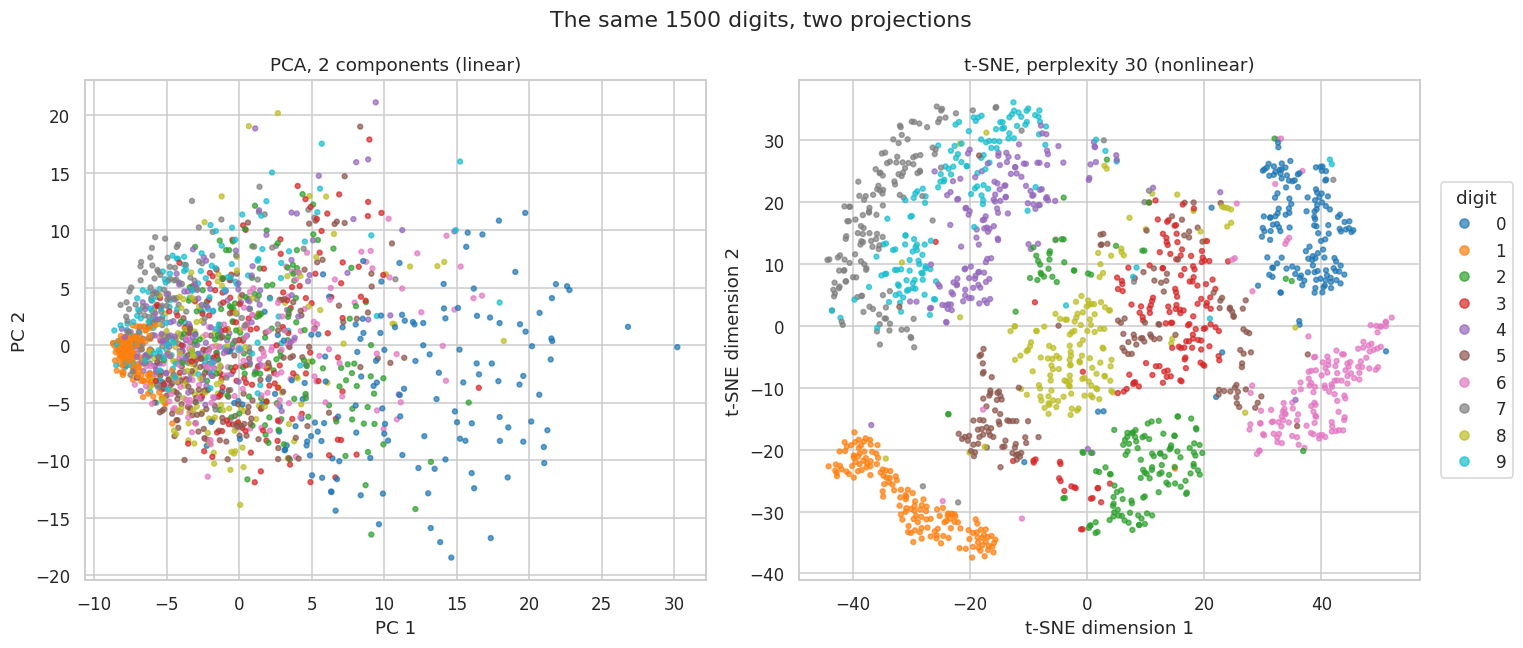

In [308]:
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

axes[0].scatter(mnist_pca_2d[:, 0], mnist_pca_2d[:, 1], c=labels, cmap="tab10", s=10, alpha=0.7)
axes[0].set_title("PCA, 2 components (linear)")
axes[0].set_xlabel("PC 1")
axes[0].set_ylabel("PC 2")

scatter = axes[1].scatter(mnist_tsne[:, 0], mnist_tsne[:, 1], c=labels, cmap="tab10", s=10, alpha=0.7)
axes[1].set_title("t-SNE, perplexity 30 (nonlinear)")
axes[1].set_xlabel("t-SNE dimension 1")
axes[1].set_ylabel("t-SNE dimension 2")

axes[1].legend(*scatter.legend_elements(), title="digit",
               loc="center left", bbox_to_anchor=(1.02, 0.5))
fig.suptitle("The same 1500 digits, two projections")
fig.tight_layout()
plt.show()

t-SNE separates the ten digits into visibly distinct islands where PCA
could not. It is a much better picture. It is also a picture you must read
with more care, and the next cell is why.

### 15.7 What t-SNE does not let you conclude

Four caveats, each of which is routinely violated in published figures.

**1. The axes mean nothing.** There is no "t-SNE dimension 1" in the sense
that there is a first principal component. The output coordinates are the
result of an optimisation and have no units and no interpretation.

**2. Distances between clusters are not meaningful.** Two islands far
apart on the page are not more different than two islands close together.
t-SNE preserves local neighbourhoods and explicitly sacrifices global
structure.

**3. Cluster sizes are not meaningful.** t-SNE expands sparse regions and
compresses dense ones. A large blob is not a more variable class.

**4. There is no `transform`.** PCA learns a projection you can apply to
new data. t-SNE does not — it places *these* points and has no rule for
placing another one. It cannot be part of a prediction pipeline.

In [309]:
print("PCA exposes a reusable transform:")
print("  hasattr(pca_2d, 'transform'):", hasattr(pca_2d, "transform"))
print("  applying it to 3 unseen rows:", pca_2d.transform(mnist_scaled[:3]).shape)
print()
print("t-SNE does not:")
print("  hasattr(tsne, 'transform'):", hasattr(tsne, "transform"))
print()
print("This is why t-SNE is a visualisation tool and not a preprocessing step.")

PCA exposes a reusable transform:
  hasattr(pca_2d, 'transform'): True
  applying it to 3 unseen rows: (3, 2)

t-SNE does not:
  hasattr(tsne, 'transform'): False

This is why t-SNE is a visualisation tool and not a preprocessing step.


### 15.8 Perplexity changes the picture

`perplexity` is roughly "how many neighbours each point should try to stay
close to". It is the single most influential setting, and the same data at
two perplexities produces two different pictures — neither of which is
more true than the other.

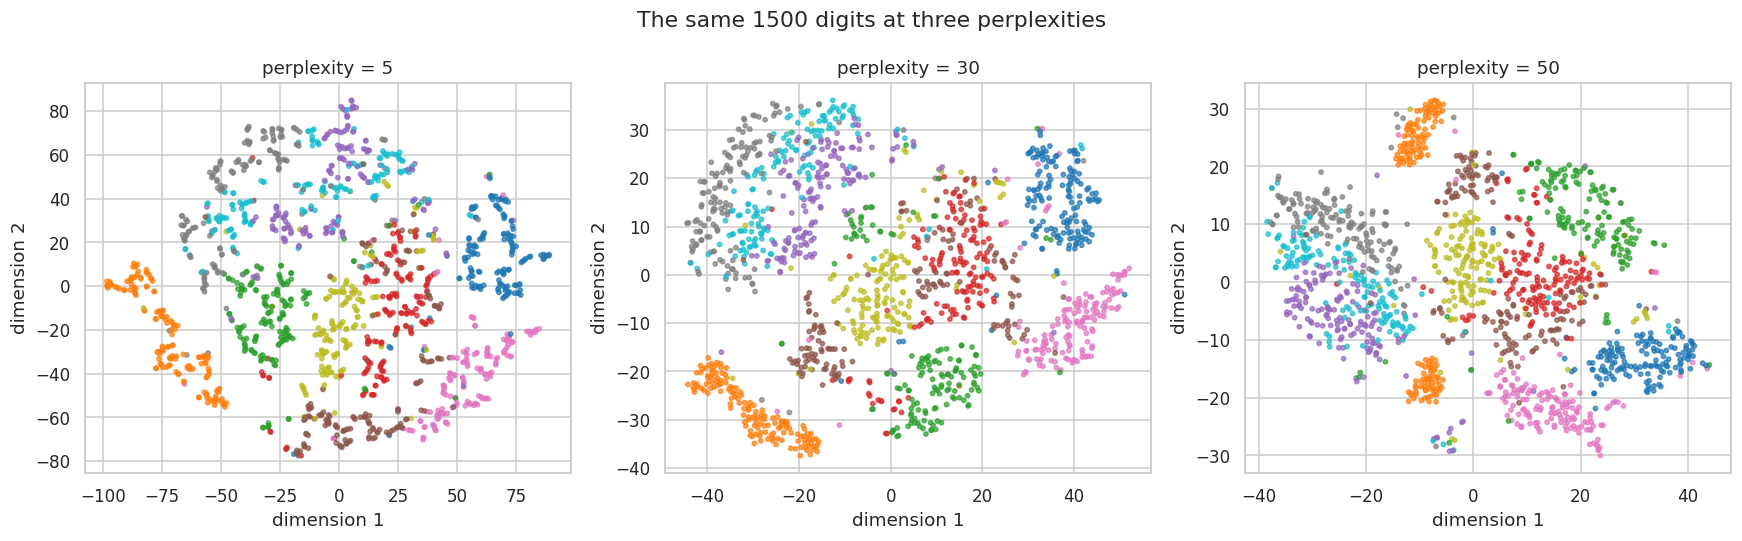

In [310]:
projections = {}
for perplexity in (5, 50):
    projections[perplexity] = TSNE(
        n_components=2, perplexity=perplexity, random_state=SEED, init="pca"
    ).fit_transform(pca_50)

fig, axes = plt.subplots(1, 3, figsize=(16, 5))
panels = [(5, projections[5]), (30, mnist_tsne), (50, projections[50])]
for ax, (perplexity, projection) in zip(axes, panels):
    ax.scatter(projection[:, 0], projection[:, 1], c=labels, cmap="tab10", s=8, alpha=0.7)
    ax.set_title(f"perplexity = {perplexity}")
    ax.set_xlabel("dimension 1")
    ax.set_ylabel("dimension 2")
fig.suptitle("The same 1500 digits at three perplexities")
fig.tight_layout()
plt.show()

At perplexity 5 the clusters shatter into many small fragments, because
each point is only trying to stay near five neighbours. At 50 they merge
into larger continents. The ten classes are equally real in all three
panels.

`random_state` matters for the same reason: t-SNE optimises from a random
start, so without a fixed seed two runs of the same code give two
different pictures. Every t-SNE in this notebook is seeded.

## 16. The two outputs Lesson 3 consumes

### 16.1 A cleaned, encoded, scaled Titanic frame

Apply every decision made above, in one place, with the reasoning attached.

In [311]:
titanic_raw = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)

decisions = []
working = titanic_raw.copy()

# 1. Cabin: 77% missing and MNAR (§5.3). Keep the fact of missingness, drop the value.
working["cabin_recorded"] = working["Cabin"].notna().astype(int)
working = working.drop(columns=["Cabin"])
decisions.append("Cabin: dropped the value (77% missing, MNAR); kept 'cabin_recorded' "
                 "as an indicator, which predicts survival at 67% against 30% (§5.3).")

# 2. Identifiers carry no signal and would be one-hot disasters (§13.4).
working = working.drop(columns=["PassengerId", "Name", "Ticket"])
decisions.append("PassengerId, Name, Ticket: dropped. Identifiers, 891/891/681 distinct "
                 "values; one-hot encoding them would produce more columns than rows (§13.4).")

# 3. Age: group-wise median, which distorts the distribution least (§5.4).
working["Age"] = working["Age"].fillna(
    working.groupby(["Pclass", "Sex"])["Age"].transform("median")
)
decisions.append("Age: 177 missing (20%), filled with the median of the passenger's "
                 "(Pclass, Sex) group. Mean-fill would have cut the standard deviation "
                 "from 14.53 to 13.00 by stacking 20% of rows on one value (§5.4).")

# 4. Embarked: mode. Defensible because it is two rows (§5.5).
working["Embarked"] = working["Embarked"].fillna(working["Embarked"].mode()[0])
decisions.append("Embarked: 2 missing (0.2%), filled with the mode 'S'. Defensible "
                 "because it is two rows, not because it is right (§5.5).")

# 5. Sex is binary; Embarked is nominal and gets one-hot, NOT label encoding (§13).
working["Sex"] = (working["Sex"] == "female").astype(int)
working = pd.get_dummies(working, columns=["Embarked"], prefix="embarked", dtype=int)
decisions.append("Sex: binary, encoded 0/1. Embarked: nominal with no ordering, so "
                 "one-hot, not LabelEncoder, which would invent C < Q < S (§13.1).")

# 6. Pclass stays an integer: the ordering 1 < 2 < 3 is real (§13.3).
decisions.append("Pclass: left as 1/2/3. The ordering is genuine, so an ordinal "
                 "encoding asserts something true (§13.3).")

print("shape:", working.shape, " missing values:", int(working.isna().sum().sum()))
working.head()

shape: (891, 11)  missing values: 0


,Survived,Pclass,Sex,Age,SibSp,Parch,Fare,cabin_recorded,embarked_C,embarked_Q,embarked_S
0,0,3,0,22.0000,1,0,7.2500,0,0,0,1
1,1,1,1,38.0000,1,0,71.2833,1,1,0,0
2,1,3,1,26.0000,0,0,7.9250,0,0,0,1
3,1,1,1,35.0000,1,0,53.1000,1,0,0,1
4,0,3,0,35.0000,0,0,8.0500,0,0,0,1


In [312]:
import pandas as pd

# завантаження Titanic
titanic_raw = pd.read_csv(
    "https://raw.githubusercontent.com/djnzx/ida-practice-3d/main/practice/datasets/titanic.csv"
)

working = titanic_raw.copy()

decisions = []

# 1. Cabin — якщо є колонка
if "Cabin" in working.columns:
    missing = working["Cabin"].isna().sum()
    working["Cabin_recorded"] = (~working["Cabin"].isna()).astype(int)
    working = working.drop(columns=["Cabin"])
    decisions.append(
        f"Cabin: dropped because it has many missing values ({missing}). "
        "Kept Cabin_recorded as a binary indicator."
    )

# 2. Ідентифікатори
drop_cols = []

for col in ["PassengerId", "Name", "Ticket"]:
    if col in working.columns:
        drop_cols.append(col)

working = working.drop(columns=drop_cols)

decisions.append(
    "PassengerId, Name and Ticket were dropped because they are identifiers "
    "and do not represent useful numerical features."
)

# 3. Age — заповнення медіаною групи
if "Age" in working.columns:
    working["Age"] = (
        working.groupby(["Pclass", "Sex"])["Age"]
        .transform(lambda x: x.fillna(x.median()))
    )

    decisions.append(
        "Age missing values were filled using median age by Pclass and Sex "
        "to preserve group differences."
    )

# 4. Embarked
if "Embarked" in working.columns:
    working["Embarked"] = working["Embarked"].fillna(
        working["Embarked"].mode()[0]
    )

    decisions.append(
        "Embarked missing values were filled with the mode because only a few "
        "rows were missing."
    )

# 5. One-hot encoding categorical variables
categorical = []

for col in ["Sex", "Embarked"]:
    if col in working.columns:
        categorical.append(col)

working = pd.get_dummies(
    working,
    columns=categorical,
    drop_first=True
)

decisions.append(
    "Sex and Embarked were one-hot encoded because they are categorical variables."
)

# 6. Pclass залишаємо як ordinal feature
if "Pclass" in working.columns:
    decisions.append(
        "Pclass was kept because passenger class has a meaningful order (1 < 2 < 3)."
    )

print("shape:", working.shape)
print("missing values:", working.isna().sum().sum())

working.head()

shape: (891, 10)
missing values: 0


,Survived,Pclass,Age,SibSp,Parch,Fare,Cabin_recorded,Sex_male,Embarked_Q,Embarked_S
0,0,3,22.0000,1,0,7.2500,0,True,False,True
1,1,1,38.0000,1,0,71.2833,1,False,False,False
2,1,3,26.0000,0,0,7.9250,0,False,False,True
3,1,1,35.0000,1,0,53.1000,1,False,False,True
4,0,3,35.0000,0,0,8.0500,0,True,False,True


In [313]:
print("Every decision made to produce that frame:\n")
for i, decision in enumerate(decisions, 1):
    print(f"{i}. {decision}\n")

Every decision made to produce that frame:

1. Cabin: dropped because it has many missing values (687). Kept Cabin_recorded as a binary indicator.

2. PassengerId, Name and Ticket were dropped because they are identifiers and do not represent useful numerical features.

3. Age missing values were filled using median age by Pclass and Sex to preserve group differences.

4. Embarked missing values were filled with the mode because only a few rows were missing.

5. Sex and Embarked were one-hot encoded because they are categorical variables.

6. Pclass was kept because passenger class has a meaningful order (1 < 2 < 3).



That list is the deliverable, as much as the table is. A cleaned dataset
without a record of how it was cleaned cannot be checked, cannot be
reproduced, and cannot be argued with.

Now split and scale, fitting the scaler on the training half only (§14.3).

In [314]:
y_titanic = working["Survived"].values
X_titanic = working.drop(columns=["Survived"])
titanic_feature_names = list(X_titanic.columns)

X_tr, X_te, y_tr, y_te = train_test_split(
    X_titanic.values, y_titanic, test_size=0.25, random_state=SEED, stratify=y_titanic
)

titanic_scaler = StandardScaler().fit(X_tr)      # fitted on training data only
X_tr_scaled = titanic_scaler.transform(X_tr)
X_te_scaled = titanic_scaler.transform(X_te)

print("features:", titanic_feature_names)
print()
print("train", X_tr_scaled.shape, " test", X_te_scaled.shape)
print("class balance in train:", np.bincount(y_tr) / len(y_tr))
print("class balance in test :", np.bincount(y_te) / len(y_te))
print()
print("stratify= preserved the 62/38 split in both halves.")

features: ['Pclass', 'Age', 'SibSp', 'Parch', 'Fare', 'Cabin_recorded', 'Sex_male', 'Embarked_Q', 'Embarked_S']

train (668, 9)  test (223, 9)
class balance in train: [0.61676647 0.38323353]
class balance in test : [0.61434978 0.38565022]

stratify= preserved the 62/38 split in both halves.


### 16.2 A two-dimensional projection of a high-dimensional dataset

Produced in §15.6: 1500 digits, 784 dimensions, reduced to 2. Practice 3 §13
clusters this projection and asks whether an algorithm with no access to
the labels recovers the ten groups.

In [315]:
print("mnist_tsne    ", mnist_tsne.shape, " the t-SNE projection")
print("mnist_pca_2d  ", mnist_pca_2d.shape, " the PCA projection")
print("pca_50        ", pca_50.shape, " 50 components, the honest input for clustering")
print("labels        ", labels.shape, " the ground truth, held back from any clustering")

mnist_tsne     (1500, 2)  the t-SNE projection
mnist_pca_2d   (1500, 2)  the PCA projection
pca_50         (1500, 50)  50 components, the honest input for clustering
labels         (1500,)  the ground truth, held back from any clustering


Note the third line. Clustering the **t-SNE output** is tempting and
wrong, for caveat 2 in §15.7: the distances t-SNE produces are not
meaningful, so a distance-based clustering of them is measuring an
artifact. Lesson 3 clusters `pca_50` and uses the t-SNE projection only to
draw the result.

## 17. Discussion

**17.1 — `df[df > 0]` returned a frame full of `NaN` rather than fewer
rows. Why?**

A boolean `DataFrame` mask operates cell by cell and the result must stay
rectangular, so failing cells are blanked rather than removed (§2.5). Row
filtering needs a boolean `Series`, one value per row.

**17.2 — After `groupby('Sex')['Age'].mean()` you cannot select the `Sex`
column. Where did it go?**

It became the index (§6.2). Use `as_index=False` or `reset_index()` to keep
it as a column.

**17.3 — You fill 20 % of a column with its mean. The mean is unchanged.
What did you damage?**

The variance, and therefore every quantity derived from it (§5.4). The
standard deviation of Titanic's `Age` falls from 14.53 to 13.00, and a
spike appears in the distribution at the fill value. Any model trained
afterwards will read that spike as real structure.

**17.4 — The 1.5 × IQR rule flags 116 fares and the 3σ rule flags 20. Which
is correct?**

Neither, and the question is malformed (§10.4). They encode different
assumptions: IQR is distribution-free and flags the whole upper tail of a
skewed variable; 3σ assumes approximate normality and its threshold is
inflated by the very extremes it is meant to detect. On `Fare` the
extremes are genuine first-class tickets, so the right answer is to flag
nothing and keep them all.

**17.5 — Why is `LabelEncoder` on `Embarked` wrong but on a target column
fine?**

On a feature it places three unordered ports on a number line, inventing
distances a model will use (§13.1). On a target the labels are never
subtracted from one another, so the encoding is a naming convention with
no geometric content.

**17.6 — A colleague fits `StandardScaler` on the whole dataset, then
splits. Their accuracy is 2 points higher than yours. Have they found
something?**

No, they have leaked (§14.3). The test rows contributed to the mean and
scale used to transform the training rows. The procedure cannot be
reproduced at prediction time, when a single new observation arrives with
no test set to fit on, so the extra 2 points describe nothing deployable.

**17.7 — Your t-SNE plot shows two clusters far apart and two close
together. What can you conclude about the four groups?**

That each of the four has internal structure worth preserving, and
essentially nothing about the distances between them (§15.7). t-SNE
preserves local neighbourhoods and discards global geometry. Re-run at
another perplexity and the arrangement changes.

**17.8 — Fare correlates with survival at +0.26 pooled and +0.001 within
third class. Which number would you report?**

Both, with the conditioning stated (§12.1). The pooled figure is real but
is mostly `Pclass` acting through fare. Reporting it alone invites the
reader to conclude that paying more improved your chances, which within a
class it essentially did not.

## 18. Summary and what comes next

- A `Series` is an array plus an index, and the index aligns operations
  silently (§2).
- `info`, `describe(include='all')` and `value_counts(dropna=False)` are
  diagnostics; the default settings of all three hide something (§3).
- Selection: `[]` for columns and boolean row filters, `.loc` for labels,
  `.iloc` for positions, and one `.loc[rows, col]` whenever assigning (§4).
- Missingness is a pattern with a mechanism — MCAR, MAR, MNAR — and four
  imputation strategies give four distributions (§5).
- Split-apply-combine, and the difference between `agg` and `transform`
  (§6).
- Dates, integer-coded categories and units someone else removed (§8).
- The chart follows from the question; bin count, bandwidth and outlier
  rule are decisions you must defend (§10).
- Pearson measures linear association and Spearman monotonic; conditioning
  can change or destroy an association (§11, §12).
- Nominal features get one-hot, ordinal features get integers, and
  `LabelEncoder` is for targets (§13).
- A scaler is fitted on training data only (§14).
- PCA is a linear projection with a reusable `transform`; t-SNE is a
  nonlinear visualisation with no `transform` and four caveats (§15).

**Lesson 3** takes `X_tr_scaled` / `X_te_scaled` from §16.1 and `pca_50`
from §16.2 and fits models to them: regression, trees, KNN, SVM,
clustering. Every preprocessing step above moves inside a `Pipeline`,
because cross-validation makes the §14.3 leak reappear in a subtler form.

### Further reading

- pandas user guide — <https://pandas.pydata.org/docs>
- pandas, indexing and selecting data —
  <https://pandas.pydata.org/docs/user_guide/indexing.html>
- seaborn tutorial — <https://seaborn.pydata.org/tutorial.html>
- scikit-learn, preprocessing data —
  <https://scikit-learn.org/stable/modules/preprocessing.html>
- How to Use t-SNE Effectively — <https://distill.pub/2016/misread-tsne/>
- Wickham, *Tidy Data*, Journal of Statistical Software 59(10) —
  <https://www.jstatsoft.org/article/view/v059i10>